# Feature-hardened ANOVA-GP workflow for NylC PA6 activity

This notebook is a methodologically extended copy of
`03_ANOVA_GP_review_HPC.ipynb`. The original notebook remains unchanged.

The added workflow:

- compares every classical descriptor family with every enabled learned embedding;
- diagnoses feature distances and RBF-kernel saturation before model fitting;
- scales length-scale candidates relative to training-only feature distances;
- applies optional PCA to learned embeddings using training data only;
- selects descriptor, representation and model family inside nested LOOCV;
- fits continuous GP hyperparameters by bounded, regularized marginal
  likelihood using only the training portion of every fold;
- checks kernel validity, leakage barriers, calibration and selection stability;
- clearly separates predictive performance from ANOVA interpretability.

ESM-2 and METL remain opt-in because they require optional dependencies and model
weights. Enabling them must never silently remove the classical baselines.


## Descriptor-source decision

The original notebook hardcoded 8 amino-acid properties. This version
avoids that by using `peptides.py`, which exposes established descriptor
families such as Kidera factors, Atchley factors, VHSE scales, Z-scales
and PCP descriptors. For a single residue, `Peptide("A").kidera_factors()`
returns the vector for that residue because the package averages over
the supplied sequence.

Documentation consulted:

- `peptides.py`: https://peptides.readthedocs.io/en/latest/
- `Peptide` API: https://peptides.readthedocs.io/en/latest/api/peptide.html
- Biopython ProtParam: https://biopython.org/docs/latest/api/Bio.SeqUtils.ProtParam.html
- modlAMP descriptors: https://modlamp.org/modlamp.html

`peptides.py` is used as the primary source because it provides compact
residue-level QSAR descriptor families. Biopython and modlAMP are useful
alternatives for sequence-level descriptors, but are less direct for the
position-wise kernel used here.

In [21]:
%pip install peptides
# Optional, only when the ESM-2 model variant is enabled below:
# %pip install transformers torch
# Optional, only when a METL variant is enabled below:
# %pip install torch git+https://github.com/gitter-lab/metl-pretrained.git


Note: you may need to restart the kernel to use updated packages.


In [22]:
from dataclasses import dataclass
from itertools import product
from pathlib import Path
import math
import platform
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import minimize
from scipy.stats import pearsonr, spearmanr, wilcoxon
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)


def find_project_root(start=None):
    start = Path.cwd() if start is None else Path(start).resolve()
    for candidate in [start] + list(start.parents):
        if (candidate / "matrices" / "NylC_Puetz_raw_data.CSV").exists():
            return candidate
    if start.name == "Notebooks":
        return start.parent
    raise FileNotFoundError("Could not locate matrices/NylC_Puetz_raw_data.CSV")


PROJECT_ROOT = find_project_root()
DATA_PATH = PROJECT_ROOT / "matrices" / "NylC_Puetz_raw_data.CSV"
OUTPUT_DIR = PROJECT_ROOT / "results" / "anova_gp_reviewed"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Python:", sys.version.split()[0])
print("Platform:", platform.platform())
print("Project root:", PROJECT_ROOT)
print("Data path:", DATA_PATH)
print("Output dir:", OUTPUT_DIR)

Python: 3.9.25
Platform: Linux-5.14.0-687.38.1.el9_8.x86_64-x86_64-with-glibc2.34
Project root: /rwthfs/rz/cluster/home/dwp46550/ba_nylon
Data path: /rwthfs/rz/cluster/home/dwp46550/ba_nylon/matrices/NylC_Puetz_raw_data.CSV
Output dir: /rwthfs/rz/cluster/home/dwp46550/ba_nylon/results/anova_gp_reviewed


In [23]:
try:
    import peptides
    from peptides import Peptide
except ImportError as exc:
    raise ImportError(
        "This notebook uses peptides.py for amino-acid descriptor vectors. "
        "Install it in the active environment, for example: pip install peptides"
    ) from exc

print("peptides.py version:", getattr(peptides, "__version__", "unknown"))

peptides.py version: 0.5.0


## Load and aggregate experimental activity

The target is the mean PA6 activity across available experimental
replicates. The SEM is retained as observation-level uncertainty and
added to the GP covariance after target standardization.

In [24]:
df_raw = pd.read_csv(DATA_PATH, sep=";", decimal=",")

activity_rep_cols = [col for col in df_raw.columns if col.startswith("activity_pa6_")]
if not activity_rep_cols:
    raise ValueError("No activity replicate columns found.")

df = df_raw.copy()
df[activity_rep_cols] = df[activity_rep_cols].apply(pd.to_numeric, errors="coerce")
df["activity_n"] = df[activity_rep_cols].count(axis=1)
df["activity_pa6"] = df[activity_rep_cols].mean(axis=1, skipna=True)
df["activity_sd"] = df[activity_rep_cols].std(axis=1, skipna=True, ddof=1)
df["activity_sem"] = df["activity_sd"] / np.sqrt(df["activity_n"])

if df["activity_pa6"].isna().any():
    raise ValueError("At least one variant has no usable PA6 activity.")

fallback_sem = df.loc[df["activity_sem"].notna() & (df["activity_sem"] > 0), "activity_sem"].median()
if not np.isfinite(fallback_sem):
    fallback_sem = 0.0
df["activity_sem_for_gp"] = df["activity_sem"].fillna(fallback_sem)

summary_cols = [
    "variant_id", "mutations", "activity_n", "activity_pa6",
    "activity_sd", "activity_sem", "activity_sem_for_gp",
]
display(df[summary_cols].head(12))
print("n variants:", len(df))
print("activity range:", (df["activity_pa6"].min(), df["activity_pa6"].max()))
print("median SEM fallback:", fallback_sem)

,variant_id,mutations,activity_n,activity_pa6,activity_sd,activity_sem,activity_sem_for_gp
0,WT,NaN,3,77.666667,2.309401,1.333333,1.333333
1,D99G,D99G,3,144.000000,19.313208,11.150486,11.150486
2,D99V,D99V,3,147.666667,6.027714,3.480102,3.480102
3,D99R,D99R,2,194.000000,14.142136,10.000000,10.000000
4,F134W,F134W,2,217.000000,7.071068,5.000000,5.000000
5,F301L,F301L,2,118.500000,4.949747,3.500000,3.500000
6,D304M,D304M,2,233.500000,3.535534,2.500000,2.500000
7,D304E,D304E,4,171.250000,9.032349,4.516175,4.516175
8,D304Q,D304Q,3,157.000000,11.135529,6.429101,6.429101
9,D304V,D304V,2,131.500000,19.091883,13.500000,13.500000


n variants: 36
activity range: (77.66666666666667, 520.0)
median SEM fallback: 6.658328118479393


## Feature sources and pocket representation

The primary model is restricted to positions 99, 134, 304 and 330.
Mutations outside this four-position space are not silently ignored;
they are excluded from the primary model.
In addition to static amino-acid descriptors, the model-selection grid can
optionally include context-dependent ESM-2 residue embeddings. The full
mutant sequence is embedded, while the ANOVA kernel still operates on the
four target positions.


In [ ]:
CANONICAL_AA = tuple("ACDEFGHIKLMNPQRSTVWY")
WT_POCKET = {99: "D", 134: "F", 304: "D", 330: "R"}
POSITIONS = tuple(WT_POCKET.keys())
TARGET_POSITIONS = set(POSITIONS)

DESCRIPTOR_SOURCES = {
    "kidera": {
        "method": "kidera_factors",
        "columns": [f"KF{i}" for i in range(1, 11)],
        "description": "Kidera factors; 10-dimensional physicochemical factors.",
    },
    "vhse": {
        "method": "vhse_scales",
        "columns": [f"VHSE{i}" for i in range(1, 9)],
        "description": "VHSE scales; hydrophobic, steric and electronic descriptors.",
    },
    "z_scales": {
        "method": "z_scales",
        "columns": [f"Z{i}" for i in range(1, 6)],
        "description": "Z-scales; compact amino-acid physicochemical descriptors.",
    },
    "atchley": {
        "method": "atchley_factors",
        "columns": [f"AF{i}" for i in range(1, 6)],
        "description": "Atchley factors; multidimensional amino-acid descriptors.",
    },
    "pcp": {
        "method": "pcp_descriptors",
        "columns": [f"PCP{i}" for i in range(1, 6)],
        "description": "Physical-chemical property descriptors from peptides.py.",
    },
    "physical": {
        "method": "physical_descriptors",
        "columns": ["PD1", "PD2"],
        "description": "Two physical descriptors; PD1 relates to volume, PD2 to hydrophilicity.",
    },
}

PRIMARY_DESCRIPTOR_SET = "kidera"

# Opt in to the Protein-LLM feature variant. Keeping this False preserves the
# lightweight descriptor-only workflow and avoids an implicit model download.
ENABLE_PROTEIN_LLM = True
PROTEIN_LLM_TARGET_VARIANT = "esm2_target"
PROTEIN_LLM_GLOBAL_DELTA_VARIANT = "esm2_global_delta"
PROTEIN_LLM_WINDOW_DELTA_VARIANT = "esm2_window_delta"
PROTEIN_LLM_VARIANTS = (
    PROTEIN_LLM_TARGET_VARIANT,
    PROTEIN_LLM_GLOBAL_DELTA_VARIANT,
    PROTEIN_LLM_WINDOW_DELTA_VARIANT,
)
PROTEIN_LLM_MODEL = "facebook/esm2_t6_8M_UR50D"
PROTEIN_LLM_BATCH_SIZE = 8
PROTEIN_LLM_DEVICE = "auto"  # CUDA when available, otherwise CPU.
PROTEIN_LLM_WINDOW_RADIUS = 16

# Frozen biophysics-pretrained METL-Global target-position embeddings.
# The two 1D checkpoints need only sequences. Enable 3D separately only
# when a single PDB chain exactly matches the 355-aa NylC WT sequence.
ENABLE_METL = True
ENABLE_METL_3D = False
# Candidate NylC structure on the HPC. The current wt.pdb contains the
# proteolytically split mature enzyme and is therefore unsuitable for METL-3D.
METL_WT_PDB = Path("/home/dwp46550/ba_nylon/boltzgen/NylC/run/wt.pdb")
METL_VARIANT_CONFIGS = {
    "metl_g_20m_1d_target": {"model_id": "metl-g-20m-1d", "pdb_path": None},
    "metl_g_50m_1d_target": {"model_id": "metl-g-50m-1d", "pdb_path": None},
}
if ENABLE_METL_3D:
    if METL_WT_PDB is None:
        raise ValueError("ENABLE_METL_3D=True requires METL_WT_PDB.")
    METL_VARIANT_CONFIGS.update({
        "metl_g_20m_3d_target": {"model_id": "metl-g-20m-3d", "pdb_path": METL_WT_PDB},
        "metl_g_50m_3d_target": {"model_id": "metl-g-50m-3d", "pdb_path": METL_WT_PDB},
    })
METL_VARIANTS = tuple(METL_VARIANT_CONFIGS)
METL_BATCH_SIZE = 4
METL_DEVICE = "auto"


@dataclass(frozen=True)
class DescriptorSource:
    name: str
    method: str
    description: str
    raw_table: pd.DataFrame
    scaled_table: pd.DataFrame


def residue_descriptor_table(source_name, standardize=True):
    if source_name not in DESCRIPTOR_SOURCES:
        raise KeyError(f"Unknown descriptor source: {source_name}")
    cfg = DESCRIPTOR_SOURCES[source_name]
    rows = {}
    for aa in CANONICAL_AA:
        values = np.asarray(getattr(Peptide(aa), cfg["method"])(), dtype=float)
        if values.shape[0] != len(cfg["columns"]):
            raise ValueError(f"Descriptor length mismatch for {source_name}:{aa}")
        rows[aa] = values
    raw = pd.DataFrame.from_dict(rows, orient="index", columns=cfg["columns"]).sort_index()
    if standardize:
        scaled = pd.DataFrame(StandardScaler().fit_transform(raw), index=raw.index, columns=raw.columns)
    else:
        scaled = raw.copy()
    return DescriptorSource(source_name, cfg["method"], cfg["description"], raw, scaled)


descriptor_source = residue_descriptor_table(PRIMARY_DESCRIPTOR_SET, standardize=True)
print(descriptor_source.name, descriptor_source.description)
display(descriptor_source.raw_table)
display(descriptor_source.scaled_table.round(3))

SCRIPTS_DIR = PROJECT_ROOT / "scripts"
if str(SCRIPTS_DIR) not in sys.path:
    sys.path.insert(0, str(SCRIPTS_DIR))

from protein_llm_embeddings import ProteinLLMEmbeddingSource, read_fasta_sequence
from metl_embeddings import METLEmbeddingSource


def make_protein_llm_source(source_name):
    representation_by_name = {
        PROTEIN_LLM_TARGET_VARIANT: "target",
        PROTEIN_LLM_GLOBAL_DELTA_VARIANT: "global_delta",
        PROTEIN_LLM_WINDOW_DELTA_VARIANT: "window_delta",
    }
    if source_name not in representation_by_name:
        raise KeyError(f"Unknown Protein-LLM source: {source_name}")
    wt_fasta = PROJECT_ROOT / "inputs" / "variant_fastas" / "WT.fasta"
    return ProteinLLMEmbeddingSource(
        wt_sequence=read_fasta_sequence(wt_fasta),
        wt_pocket=WT_POCKET,
        model_name=PROTEIN_LLM_MODEL,
        cache_dir=PROJECT_ROOT / "results" / "protein_llm_embedding_cache",
        batch_size=PROTEIN_LLM_BATCH_SIZE,
        device=PROTEIN_LLM_DEVICE,
        representation=representation_by_name[source_name],
        window_radius=PROTEIN_LLM_WINDOW_RADIUS,
        name=source_name,
    )



AA3_TO_AA1 = {
    "ALA": "A", "CYS": "C", "ASP": "D", "GLU": "E", "PHE": "F",
    "GLY": "G", "HIS": "H", "ILE": "I", "LYS": "K", "LEU": "L",
    "MET": "M", "ASN": "N", "PRO": "P", "GLN": "Q", "ARG": "R",
    "SER": "S", "THR": "T", "VAL": "V", "TRP": "W", "TYR": "Y",
    "MSE": "M",
}


def validate_pdb_contains_exact_sequence(pdb_path, expected_sequence):
    """Require at least one PDB chain with an exact CA-based FASTA match."""
    chains = {}
    seen = set()
    with Path(pdb_path).open("r", encoding="utf-8", errors="replace") as handle:
        for line in handle:
            if not line.startswith(("ATOM  ", "HETATM")) or line[12:16].strip() != "CA":
                continue
            altloc = line[16:17]
            if altloc not in {" ", "A"}:
                continue
            chain = line[21:22].strip() or "_"
            residue_key = (chain, line[22:26], line[26:27])
            if residue_key in seen:
                continue
            seen.add(residue_key)
            residue = line[17:20].strip().upper()
            if residue not in AA3_TO_AA1:
                raise ValueError(f"Unsupported PDB residue {residue!r} in chain {chain}")
            chains.setdefault(chain, []).append(AA3_TO_AA1[residue])
    chain_sequences = {chain: "".join(values) for chain, values in chains.items()}
    matching = [chain for chain, sequence in chain_sequences.items() if sequence == expected_sequence]
    if not matching:
        lengths = {chain: len(sequence) for chain, sequence in chain_sequences.items()}
        raise ValueError(
            "METL-3D requires an exact sequence-matched PDB chain; "
            f"expected length {len(expected_sequence)}, observed chain lengths {lengths}. "
            "Do not concatenate or pad split chains without a validated residue mapping. "
            "Set ENABLE_METL_3D=False to use the sequence-only METL models."
        )
    return matching


def make_metl_source(source_name):
    if source_name not in METL_VARIANT_CONFIGS:
        raise KeyError(f"Unknown METL source: {source_name}")
    cfg = METL_VARIANT_CONFIGS[source_name]
    wt_fasta = PROJECT_ROOT / "inputs" / "variant_fastas" / "WT.fasta"
    wt_sequence = read_fasta_sequence(wt_fasta)
    if cfg["pdb_path"] is not None:
        matching_chains = validate_pdb_contains_exact_sequence(cfg["pdb_path"], wt_sequence)
        print(f"Validated METL PDB sequence in chain(s): {matching_chains}")
    return METLEmbeddingSource(
        wt_sequence=wt_sequence,
        wt_pocket=WT_POCKET,
        model_id=cfg["model_id"],
        pdb_path=cfg["pdb_path"],
        cache_dir=PROJECT_ROOT / "results" / "metl_embedding_cache",
        batch_size=METL_BATCH_SIZE,
        device=METL_DEVICE,
        name=source_name,
    )


def make_feature_source(source_name):
    if source_name in PROTEIN_LLM_VARIANTS:
        return make_protein_llm_source(source_name)
    if source_name in METL_VARIANTS:
        return make_metl_source(source_name)
    return residue_descriptor_table(source_name, standardize=True)


learned_feature_sources = ()
if ENABLE_PROTEIN_LLM:
    learned_feature_sources += PROTEIN_LLM_VARIANTS
if ENABLE_METL:
    learned_feature_sources += METL_VARIANTS
# Always retain all classical baselines when optional learned sources are enabled.
# This makes comparisons fair: an embedding must beat the best classical source,
# not merely the initially chosen Kidera baseline.
AVAILABLE_FEATURE_SOURCES = tuple(dict.fromkeys(
    tuple(DESCRIPTOR_SOURCES) + learned_feature_sources
))
print("Feature-source variants:", AVAILABLE_FEATURE_SOURCES)


kidera Kidera factors; 10-dimensional physicochemical factors.


,KF1,KF2,KF3,KF4,KF5,KF6,KF7,KF8,KF9,KF10
A,-1.56,-1.67,-0.97,-0.27,-0.93,-0.78,-0.20,-0.08,0.21,-0.48
C,0.12,-0.89,0.45,-1.05,-0.71,2.41,1.52,-0.69,1.13,1.10
D,0.58,-0.22,-1.58,0.81,-0.92,0.15,-1.52,0.47,0.76,0.70
E,-1.45,0.19,-1.61,1.17,-1.31,0.40,0.04,0.38,-0.35,-0.12
F,-0.21,0.98,-0.36,-1.43,0.22,-0.81,0.67,1.10,1.71,-0.44
G,1.46,-1.96,-0.23,-0.16,0.10,-0.11,1.32,2.36,-1.66,0.46
H,-0.41,0.52,-0.28,0.28,1.61,1.01,-1.85,0.47,1.13,1.63
I,-0.73,-0.16,1.79,-0.77,-0.54,0.03,-0.83,0.51,0.66,-1.78
K,-0.34,0.82,-0.23,1.70,1.54,-1.62,1.15,-0.08,-0.48,0.60
L,-1.04,0.00,-0.24,-1.10,-0.55,-2.05,0.96,-0.76,0.45,0.93


,KF1,KF2,KF3,KF4,KF5,KF6,KF7,KF8,KF9,KF10
A,-1.559,-1.669,-0.969,-0.270,-0.928,-0.779,-0.199,-0.080,0.210,-0.480
C,0.121,-0.889,0.451,-1.050,-0.708,2.411,1.520,-0.690,1.130,1.100
D,0.581,-0.219,-1.579,0.810,-0.918,0.151,-1.518,0.469,0.760,0.700
E,-1.449,0.190,-1.609,1.170,-1.307,0.401,0.041,0.379,-0.349,-0.120
F,-0.209,0.980,-0.359,-1.430,0.219,-0.809,0.671,1.099,1.709,-0.440
G,1.461,-1.959,-0.229,-0.160,0.100,-0.109,1.320,2.358,-1.658,0.460
H,-0.409,0.520,-0.279,0.280,1.606,1.011,-1.848,0.469,1.130,1.630
I,-0.729,-0.159,1.790,-0.770,-0.539,0.031,-0.828,0.509,0.660,-1.780
K,-0.339,0.820,-0.229,1.699,1.536,-1.619,1.150,-0.080,-0.479,0.600
L,-1.039,0.000,-0.239,-1.100,-0.549,-2.049,0.960,-0.760,0.450,0.930


Feature-source variants: ('kidera', 'vhse', 'z_scales', 'atchley', 'pcp', 'physical')


### Enabling the Protein-LLM variant

Set `ENABLE_PROTEIN_LLM = True` in the feature-source cell and install
`transformers` plus `torch`. The default model is the compact
`facebook/esm2_t6_8M_UR50D`; change `PROTEIN_LLM_MODEL` for a larger
ESM-2 checkpoint. Embeddings are cached by model, sequence and target
positions under `results/protein_llm_embedding_cache`, so nested LOOCV
does not repeatedly run the language model. The enabled comparison contains exactly four feature representations:
Kidera, target-position ESM-2, global full-protein WT-delta ESM-2,
and local-window WT-delta ESM-2. The global delta uses a direct RBF-GP;
the other representations use the additive/epistatic ANOVA-GP.
Model/feature-source selection remains inside the inner LOOCV loop.


### Enabling the METL variants

Set `ENABLE_METL = True` and install the official `metl-pretrained` package.
The configured 20M and 50M METL-Global 1D source models provide frozen,
biophysics-pretrained residue embeddings at positions 99, 134, 304 and 330.
They use the same additive/epistatic ANOVA-GP as the ESM-2 target variant
and are cached under `results/metl_embedding_cache`. To add a 3D METL
checkpoint, set `ENABLE_METL_3D = True` and assign `METL_WT_PDB` to a WT
PDB whose single-chain residue sequence exactly matches the 355-residue model
input. The split mature-enzyme `wt.pdb` is intentionally rejected; keep the
3D switch false until a scientifically validated full-length structure exists.


In [26]:
import re

MUTATION_PATTERN = re.compile(r"([A-Z])(\d+)([A-Z])")


def parse_mutations(mutation_string):
    pocket = dict(WT_POCKET)
    if pd.isna(mutation_string) or str(mutation_string).strip().lower() in {
        "", "wt", "wildtype", "wild type", "nan",
    }:
        return pocket, []
    mutations = []
    for wt_aa, pos_str, mut_aa in MUTATION_PATTERN.findall(str(mutation_string).upper()):
        pos = int(pos_str)
        mutations.append((wt_aa, pos, mut_aa))
        if pos in WT_POCKET:
            expected = WT_POCKET[pos]
            if wt_aa != expected:
                warnings.warn(
                    f"Mutation {wt_aa}{pos}{mut_aa} does not match expected WT {expected}{pos}.",
                    RuntimeWarning,
                )
            pocket[pos] = mut_aa
    return pocket, mutations


def aa_tuple_from_pocket(pocket, positions=POSITIONS):
    return tuple(pocket[pos] for pos in positions)


def mutation_positions(all_mutations):
    return {pos for _, pos, _ in all_mutations}


def mutation_signature(positions):
    if not positions:
        return "WT"
    return "+".join(str(pos) for pos in sorted(positions))


parsed = df["mutations"].apply(parse_mutations)
df_model = df.copy()
df_model["pocket"] = parsed.apply(lambda item: item[0])
df_model["all_mutations"] = parsed.apply(lambda item: item[1])
df_model["aa_tuple"] = df_model["pocket"].apply(aa_tuple_from_pocket)
df_model["mutation_positions"] = df_model["all_mutations"].apply(mutation_positions)
df_model["mutation_signature"] = df_model["mutation_positions"].apply(mutation_signature)
df_model["mutation_order"] = df_model["all_mutations"].apply(len)
df_model["only_target_positions"] = df_model["mutation_positions"].apply(lambda s: s.issubset(TARGET_POSITIONS))

df_core = df_model[df_model["only_target_positions"]].copy().reset_index(drop=True)
df_excluded = df_model[~df_model["only_target_positions"]].copy()

print("Full dataset:", df_model.shape)
print("Core four-position dataset:", df_core.shape)
print("Excluded variants because of external mutations:")
display(df_excluded[["variant_id", "mutations", "mutation_positions"]])
display(df_core[["variant_id", "mutations", "aa_tuple", "mutation_signature", "mutation_order", "activity_pa6"]].head(15))

Full dataset: (36, 23)
Core four-position dataset: (35, 23)
Excluded variants because of external mutations:


,variant_id,mutations,mutation_positions
5,F301L,F301L,{301}


,variant_id,mutations,aa_tuple,mutation_signature,mutation_order,activity_pa6
0,WT,NaN,"(D, F, D, R)",WT,0,77.666667
1,D99G,D99G,"(G, F, D, R)",99,1,144.000000
2,D99V,D99V,"(V, F, D, R)",99,1,147.666667
3,D99R,D99R,"(R, F, D, R)",99,1,194.000000
4,F134W,F134W,"(D, W, D, R)",134,1,217.000000
5,D304M,D304M,"(D, F, M, R)",304,1,233.500000
6,D304E,D304E,"(D, F, E, R)",304,1,171.250000
7,D304Q,D304Q,"(D, F, Q, R)",304,1,157.000000
8,D304V,D304V,"(D, F, V, R)",304,1,131.500000
9,D304W,D304W,"(D, F, W, R)",304,1,130.000000


## ANOVA-GP implementation

The additive baseline uses only position-wise main effects. The epistatic
model adds pairwise products between position-specific kernels. Setting
`sigma_epi = 0` gives the additive model.

In [27]:
def aa_descriptor_vector(aa, source):
    aa = str(aa).upper()
    if aa not in source.scaled_table.index:
        raise ValueError(f"Unknown or unsupported amino acid: {aa}")
    return source.scaled_table.loc[aa].to_numpy(dtype=float)


def pockets_to_position_descriptor_arrays(pockets, source, positions=POSITIONS):
    # Contextual sources (currently ESM-2) embed the complete mutant sequence.
    # Static descriptor sources retain the original residue lookup behavior.
    if hasattr(source, "position_arrays"):
        return source.position_arrays(pockets, positions=positions)
    arrays = {}
    for pos in positions:
        arrays[pos] = np.vstack([aa_descriptor_vector(pocket[pos], source) for pocket in pockets])
    return arrays


def rbf_kernel_from_descriptors(X1, X2=None, lengthscale=1.0):
    if X2 is None:
        X2 = X1
    X1 = np.asarray(X1, dtype=float)
    X2 = np.asarray(X2, dtype=float)
    squared_distances = ((X1[:, None, :] - X2[None, :, :]) ** 2).sum(axis=2)
    return np.exp(-squared_distances / (2.0 * float(lengthscale) ** 2))


def normalize_lengthscales(lengthscales, positions=POSITIONS):
    if isinstance(lengthscales, dict):
        return {pos: float(lengthscales[pos]) for pos in positions}
    return {pos: float(lengthscales) for pos in positions}


def build_position_kernels(position_arrays, lengthscales=1.0):
    ls = normalize_lengthscales(lengthscales, positions=position_arrays.keys())
    return {
        pos: rbf_kernel_from_descriptors(X_pos, lengthscale=ls[pos])
        for pos, X_pos in position_arrays.items()
    }


def build_position_cross_kernels(train_pockets, test_pockets, source, lengthscales=1.0, positions=POSITIONS):
    ls = normalize_lengthscales(lengthscales, positions=positions)
    train_arrays = pockets_to_position_descriptor_arrays(train_pockets, source, positions=positions)
    test_arrays = pockets_to_position_descriptor_arrays(test_pockets, source, positions=positions)
    return {
        pos: rbf_kernel_from_descriptors(test_arrays[pos], X2=train_arrays[pos], lengthscale=ls[pos])
        for pos in positions
    }


def build_main_kernel(position_kernels):
    return np.mean(np.stack(list(position_kernels.values()), axis=0), axis=0)


def build_epistasis_kernel(position_kernels):
    positions = list(position_kernels)
    products = []
    for i, pos_a in enumerate(positions):
        for pos_b in positions[i + 1:]:
            products.append(position_kernels[pos_a] * position_kernels[pos_b])
    if not products:
        raise ValueError("At least two positions are required for pairwise epistasis.")
    return np.mean(np.stack(products, axis=0), axis=0)


def build_total_anova_kernel(position_kernels, sigma_main=1.0, sigma_epi=0.0):
    k_main = build_main_kernel(position_kernels)
    k_epi = build_epistasis_kernel(position_kernels)
    k_total = float(sigma_main) ** 2 * k_main + float(sigma_epi) ** 2 * k_epi
    return k_total, k_main, k_epi


def build_total_cross_kernel(train_pockets, test_pockets, source, lengthscales=1.0, sigma_main=1.0, sigma_epi=0.0):
    cross = build_position_cross_kernels(train_pockets, test_pockets, source, lengthscales=lengthscales)
    k_main = build_main_kernel(cross)
    k_epi = build_epistasis_kernel(cross)
    return float(sigma_main) ** 2 * k_main + float(sigma_epi) ** 2 * k_epi


position_arrays = pockets_to_position_descriptor_arrays(df_core["pocket"].tolist(), descriptor_source)
position_kernels = build_position_kernels(position_arrays, lengthscales=1.0)
K_total_test, _, _ = build_total_anova_kernel(position_kernels, sigma_main=1.0, sigma_epi=1.0)
print("K_total shape:", K_total_test.shape)
print("symmetric:", np.allclose(K_total_test, K_total_test.T))
print("diag range:", np.diag(K_total_test).min(), np.diag(K_total_test).max())

K_total shape: (35, 35)
symmetric: True
diag range: 2.0 2.0


In [28]:
def standardize_target(y):
    y = np.asarray(y, dtype=float)
    y_mean = float(np.mean(y))
    y_std = float(np.std(y, ddof=1))
    if not np.isfinite(y_std) or y_std <= 0:
        raise ValueError("Target has zero or invalid standard deviation.")
    return (y - y_mean) / y_std, y_mean, y_std


def fit_gp_from_kernel(K_total, y, sem=None, sigma_noise=0.5, jitter=1e-8):
    y_scaled, y_mean, y_std = standardize_target(y)
    n = len(y_scaled)
    if sem is None:
        sem_scaled = np.zeros(n)
    else:
        sem_scaled = np.asarray(sem, dtype=float) / y_std
        sem_scaled = np.nan_to_num(sem_scaled, nan=0.0, posinf=0.0, neginf=0.0)
    K_y = (
        np.asarray(K_total, dtype=float)
        + np.diag(sem_scaled ** 2)
        + float(sigma_noise) ** 2 * np.eye(n)
        + float(jitter) * np.eye(n)
    )
    L = np.linalg.cholesky(K_y)
    alpha = np.linalg.solve(L.T, np.linalg.solve(L, y_scaled))
    return {
        "K_total": K_total,
        "K_y": K_y,
        "L": L,
        "alpha": alpha,
        "y_mean": y_mean,
        "y_std": y_std,
        "sigma_noise": float(sigma_noise),
        "sem_scaled": sem_scaled,
    }


def gp_predict_from_fit(gp_fit, K_test_train, K_test_diag):
    K_test_train = np.asarray(K_test_train, dtype=float)
    K_test_diag = np.asarray(K_test_diag, dtype=float)
    mean_scaled = K_test_train @ gp_fit["alpha"]
    v = np.linalg.solve(gp_fit["L"], K_test_train.T)
    var_latent_scaled = np.maximum(K_test_diag - np.sum(v ** 2, axis=0), 0.0)
    var_observed_scaled = var_latent_scaled + gp_fit["sigma_noise"] ** 2
    return {
        "mean": gp_fit["y_mean"] + gp_fit["y_std"] * mean_scaled,
        "std_latent": gp_fit["y_std"] * np.sqrt(var_latent_scaled),
        "std_observed": gp_fit["y_std"] * np.sqrt(var_observed_scaled),
    }


def gaussian_nlpd(y_true, y_pred, std):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    std = np.maximum(np.asarray(std, dtype=float), 1e-9)
    return float(np.mean(0.5 * np.log(2 * np.pi * std ** 2) + 0.5 * ((y_true - y_pred) / std) ** 2))


def regression_metrics(y_true, y_pred, pred_std_observed=None):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    out = {
        "mae": mean_absolute_error(y_true, y_pred),
        "rmse": math.sqrt(mean_squared_error(y_true, y_pred)),
        "r2": r2_score(y_true, y_pred),
        "pearson": pearsonr(y_true, y_pred).statistic if len(y_true) > 2 else np.nan,
        "spearman": spearmanr(y_true, y_pred).statistic if len(y_true) > 2 else np.nan,
    }
    if pred_std_observed is not None:
        out["nlpd_observed"] = gaussian_nlpd(y_true, y_pred, pred_std_observed)
    return out

## Feature-space and kernel diagnostics

RBF length scales are meaningful only relative to distances in the corresponding
feature space. A fixed numerical length scale is not directly comparable between
2-dimensional physical descriptors, 10-dimensional Kidera factors and
high-dimensional embeddings.

The following diagnostics therefore inspect, for every enabled source:

1. finite feature values and matrix dimensions;
2. non-zero pairwise training distances;
3. RBF off-diagonal distributions;
4. kernel saturation near zero or one;
5. symmetry, unit diagonal and positive semidefiniteness.

The diagnostic reference length scale is the median non-zero distance. This is a
diagnostic, not a fitted biological parameter.


In [29]:
from sklearn.decomposition import PCA
from sklearn.metrics import pairwise_distances


CLASSICAL_DESCRIPTOR_NAMES = tuple(DESCRIPTOR_SOURCES)
LEARNED_SOURCE_PREFIXES = ("esm2_", "metl_")


def is_learned_source_name(source_name):
    return str(source_name).startswith(LEARNED_SOURCE_PREFIXES)


def positive_pairwise_distances(X):
    X = np.asarray(X, dtype=float)
    if X.ndim != 2 or X.shape[0] < 2:
        return np.array([], dtype=float)
    distances = pairwise_distances(X, metric="euclidean")
    values = distances[np.triu_indices_from(distances, k=1)]
    return values[np.isfinite(values) & (values > 1e-12)]


def source_training_arrays(pockets, source, positions=POSITIONS):
    if getattr(source, "representation", None) == "global_delta":
        return {"global": np.asarray(source.feature_matrix(pockets), dtype=float)}
    return {
        pos: np.asarray(values, dtype=float)
        for pos, values in pockets_to_position_descriptor_arrays(
            pockets, source, positions=positions
        ).items()
    }


def robust_distance_scale(feature_arrays):
    values = []
    for X in feature_arrays.values():
        values.extend(positive_pairwise_distances(X).tolist())
    values = np.asarray(values, dtype=float)
    if values.size == 0:
        raise ValueError("No non-zero pairwise feature distances are available.")
    return float(np.median(values))


def feature_source_diagnostics(df_eval, source):
    arrays = source_training_arrays(df_eval["pocket"].tolist(), source)
    rows = []
    for component, X in arrays.items():
        if not np.isfinite(X).all():
            raise AssertionError(f"Non-finite features for {source.name}:{component}")
        distances = positive_pairwise_distances(X)
        if distances.size == 0:
            rows.append({
                "source": source.name,
                "component": component,
                "n": X.shape[0],
                "dimension": X.shape[1],
                "n_nonzero_distances": 0,
                "median_distance": np.nan,
                "q10_distance": np.nan,
                "q90_distance": np.nan,
                "fraction_kernel_lt_1e-3": np.nan,
                "fraction_kernel_gt_0p9": np.nan,
                "min_kernel_eigenvalue": np.nan,
            })
            continue
        reference_lengthscale = float(np.median(distances))
        K = rbf_kernel_from_descriptors(X, lengthscale=reference_lengthscale)
        offdiag = K[np.triu_indices_from(K, k=1)]
        rows.append({
            "source": source.name,
            "component": component,
            "n": X.shape[0],
            "dimension": X.shape[1],
            "n_nonzero_distances": distances.size,
            "median_distance": reference_lengthscale,
            "q10_distance": float(np.quantile(distances, 0.10)),
            "q90_distance": float(np.quantile(distances, 0.90)),
            "fraction_kernel_lt_1e-3": float(np.mean(offdiag < 1e-3)),
            "fraction_kernel_gt_0p9": float(np.mean(offdiag > 0.9)),
            "min_kernel_eigenvalue": float(np.linalg.eigvalsh((K + K.T) / 2).min()),
        })
    return pd.DataFrame(rows)


diagnostic_sources = {
    name: make_feature_source(name)
    for name in AVAILABLE_FEATURE_SOURCES
}
feature_diagnostics = pd.concat(
    [feature_source_diagnostics(df_core, source) for source in diagnostic_sources.values()],
    ignore_index=True,
)

display(feature_diagnostics)
feature_diagnostics.to_csv(OUTPUT_DIR / "feature_distance_kernel_diagnostics.csv", index=False)


,source,component,n,dimension,n_nonzero_distances,median_distance,q10_distance,q90_distance,fraction_kernel_lt_1e-3,fraction_kernel_gt_0p9,min_kernel_eigenvalue
0,kidera,99,35,10,378,4.618280,4.459457e+00,5.019001,0.0,0.374790,-5.415130e-15
1,kidera,134,35,10,504,5.011116,8.429370e-08,5.011116,0.0,0.505882,-8.637635e-15
2,kidera,304,35,10,547,4.618280,5.960464e-08,5.074254,0.0,0.220168,-4.228879e-15
3,kidera,330,35,10,294,4.737383,4.450296e+00,5.226954,0.0,0.505882,-7.406287e-15
4,vhse,99,35,8,389,5.230977,5.091522e+00,6.139122,0.0,0.374790,-4.368430e-15
5,vhse,134,35,8,294,2.191009,2.191009e+00,2.191009,0.0,0.505882,-5.982498e-15
6,vhse,304,35,8,465,4.476646,2.096535e+00,5.212989,0.0,0.265546,-5.129524e-15
7,vhse,330,35,8,570,2.961779,5.960464e-08,5.735471,0.0,0.505882,-3.567908e-15
8,z_scales,99,35,5,372,3.855501,3.051292e+00,4.275935,0.0,0.374790,-6.984965e-15
9,z_scales,134,35,5,385,2.123860,2.980232e-08,2.123860,0.0,0.505882,-1.067032e-14


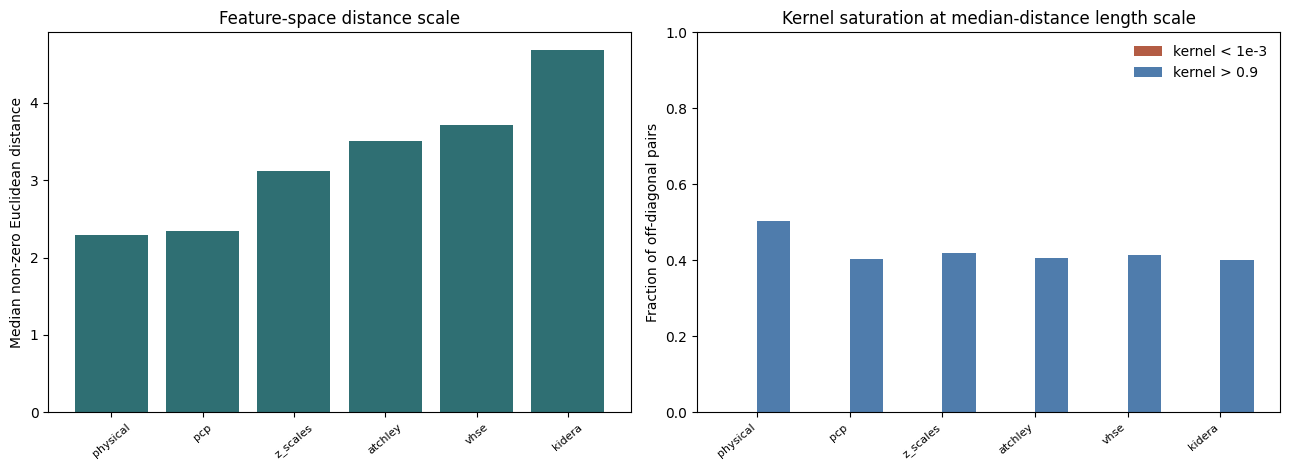

In [30]:
# Plot 1: distance scale and RBF saturation by feature source.
diagnostic_plot = (
    feature_diagnostics
    .groupby("source", as_index=False)
    .agg(
        median_distance=("median_distance", "median"),
        median_dimension=("dimension", "median"),
        fraction_near_zero=("fraction_kernel_lt_1e-3", "mean"),
        fraction_near_one=("fraction_kernel_gt_0p9", "mean"),
    )
    .sort_values("median_distance")
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
axes[0].bar(diagnostic_plot["source"], diagnostic_plot["median_distance"], color="#2f6f73")
axes[0].set_ylabel("Median non-zero Euclidean distance")
axes[0].set_title("Feature-space distance scale")
axes[0].tick_params(axis="x", rotation=40, labelsize=8)

x = np.arange(len(diagnostic_plot))
axes[1].bar(x - 0.18, diagnostic_plot["fraction_near_zero"], 0.36, label="kernel < 1e-3", color="#b35c44")
axes[1].bar(x + 0.18, diagnostic_plot["fraction_near_one"], 0.36, label="kernel > 0.9", color="#4f7cac")
axes[1].set_xticks(x, diagnostic_plot["source"], rotation=40, ha="right", fontsize=8)
axes[1].set_ylim(0, 1)
axes[1].set_ylabel("Fraction of off-diagonal pairs")
axes[1].set_title("Kernel saturation at median-distance length scale")
axes[1].legend(frameon=False)

fig.tight_layout()
fig.savefig(OUTPUT_DIR / "feature_distance_and_kernel_saturation.png", dpi=300, bbox_inches="tight")
plt.show()


### Kernel diagnostics excluding identical feature pairs

The previous off-diagonal summary includes pairs of variants with identical
features at a position. Such pairs necessarily have distance zero and kernel
similarity one. They are biologically meaningful duplicates, but they do not
show whether the kernel distinguishes different amino acids or embedding
states.

The following analysis therefore reports separately:

- the fraction of identical off-diagonal feature pairs;
- kernel statistics only for pairs with positive feature distance;
- the effect of length-scale multipliers (c\in\{0.5,1,2\}), with
  \(\ell=c\,m\) and training distance scale (m);
- quantiles and saturation fractions for the non-identical pairs.

For static descriptors, positive distance is equivalent to a different
amino-acid descriptor vector. For learned embeddings it means a different
contextual representation and is therefore not necessarily equivalent to a
different residue identity.


In [31]:
KERNEL_DIAGNOSTIC_MULTIPLIERS = (0.5, 1.0, 2.0)


def nonidentical_kernel_diagnostics(df_eval, source, multipliers=KERNEL_DIAGNOSTIC_MULTIPLIERS):
    arrays = source_training_arrays(df_eval["pocket"].tolist(), source)
    reference_scale = robust_distance_scale(arrays)
    rows = []
    distributions = []

    for component, X in arrays.items():
        distances_matrix = pairwise_distances(np.asarray(X, dtype=float), metric="euclidean")
        distances = distances_matrix[np.triu_indices_from(distances_matrix, k=1)]
        finite = np.isfinite(distances)
        identical = finite & (distances <= 1e-12)
        nonidentical_distances = distances[finite & ~identical]
        n_finite = int(finite.sum())

        if nonidentical_distances.size == 0:
            continue

        for multiplier in multipliers:
            lengthscale = float(multiplier) * reference_scale
            similarities = np.exp(
                -(nonidentical_distances ** 2) / (2.0 * lengthscale ** 2)
            )
            rows.append({
                "source": source.name,
                "component": component,
                "lengthscale_multiplier": float(multiplier),
                "reference_distance_scale": reference_scale,
                "resolved_lengthscale": lengthscale,
                "n_finite_offdiagonal_pairs": n_finite,
                "n_identical_pairs": int(identical.sum()),
                "fraction_identical_pairs": float(identical.sum() / n_finite),
                "n_nonidentical_pairs": int(nonidentical_distances.size),
                "kernel_q05_nonidentical": float(np.quantile(similarities, 0.05)),
                "kernel_q25_nonidentical": float(np.quantile(similarities, 0.25)),
                "kernel_median_nonidentical": float(np.median(similarities)),
                "kernel_q75_nonidentical": float(np.quantile(similarities, 0.75)),
                "kernel_q95_nonidentical": float(np.quantile(similarities, 0.95)),
                "fraction_nonidentical_kernel_lt_1e-3": float(np.mean(similarities < 1e-3)),
                "fraction_nonidentical_kernel_lt_0p01": float(np.mean(similarities < 0.01)),
                "fraction_nonidentical_kernel_gt_0p9": float(np.mean(similarities > 0.9)),
            })
            distributions.extend({
                "source": source.name,
                "component": component,
                "lengthscale_multiplier": float(multiplier),
                "kernel_similarity": float(value),
            } for value in similarities)

    return pd.DataFrame(rows), pd.DataFrame(distributions)


nonidentical_summary_parts = []
nonidentical_distribution_parts = []
for source in diagnostic_sources.values():
    summary_part, distribution_part = nonidentical_kernel_diagnostics(df_core, source)
    nonidentical_summary_parts.append(summary_part)
    nonidentical_distribution_parts.append(distribution_part)

nonidentical_kernel_summary = pd.concat(nonidentical_summary_parts, ignore_index=True)
nonidentical_kernel_distributions = pd.concat(
    nonidentical_distribution_parts, ignore_index=True
)

display(nonidentical_kernel_summary)
nonidentical_kernel_summary.to_csv(
    OUTPUT_DIR / "nonidentical_pair_kernel_diagnostics.csv", index=False
)


,source,component,lengthscale_multiplier,reference_distance_scale,resolved_lengthscale,n_finite_offdiagonal_pairs,n_identical_pairs,fraction_identical_pairs,n_nonidentical_pairs,kernel_q05_nonidentical,kernel_q25_nonidentical,kernel_median_nonidentical,kernel_q75_nonidentical,kernel_q95_nonidentical,fraction_nonidentical_kernel_lt_1e-3,fraction_nonidentical_kernel_lt_0p01,fraction_nonidentical_kernel_gt_0p9
0,kidera,99,0.5,4.737383,2.368692,595,217,0.364706,378,0.049690,0.105943,0.149464,0.169956,0.169956,0.000000,0.000000,0.015873
1,kidera,99,1.0,4.737383,4.737383,595,217,0.364706,378,0.472135,0.570517,0.621776,0.642072,0.642072,0.000000,0.000000,0.015873
2,kidera,99,2.0,4.737383,9.474767,595,217,0.364706,378,0.828928,0.869095,0.887991,0.895150,0.895150,0.000000,0.000000,0.015873
3,kidera,134,0.5,4.737383,2.368692,595,91,0.152941,504,0.106693,0.106693,0.106693,1.000000,1.000000,0.000000,0.000000,0.416667
4,kidera,134,1.0,4.737383,4.737383,595,91,0.152941,504,0.571523,0.571523,0.571523,1.000000,1.000000,0.000000,0.000000,0.416667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67,physical,304,1.0,1.685150,1.685150,595,130,0.218487,465,0.256050,0.261345,0.303157,0.805989,0.992760,0.000000,0.000000,0.172043
68,physical,304,2.0,1.685150,3.370299,595,130,0.218487,465,0.711347,0.714996,0.742022,0.947507,0.998185,0.000000,0.000000,0.266667
69,physical,330,0.5,1.685150,0.842575,595,301,0.505882,294,0.000153,0.000153,0.007027,0.454246,0.454246,0.489796,0.591837,0.000000
70,physical,330,1.0,1.685150,1.685150,595,301,0.505882,294,0.111230,0.111230,0.289530,0.820961,0.820961,0.000000,0.000000,0.000000


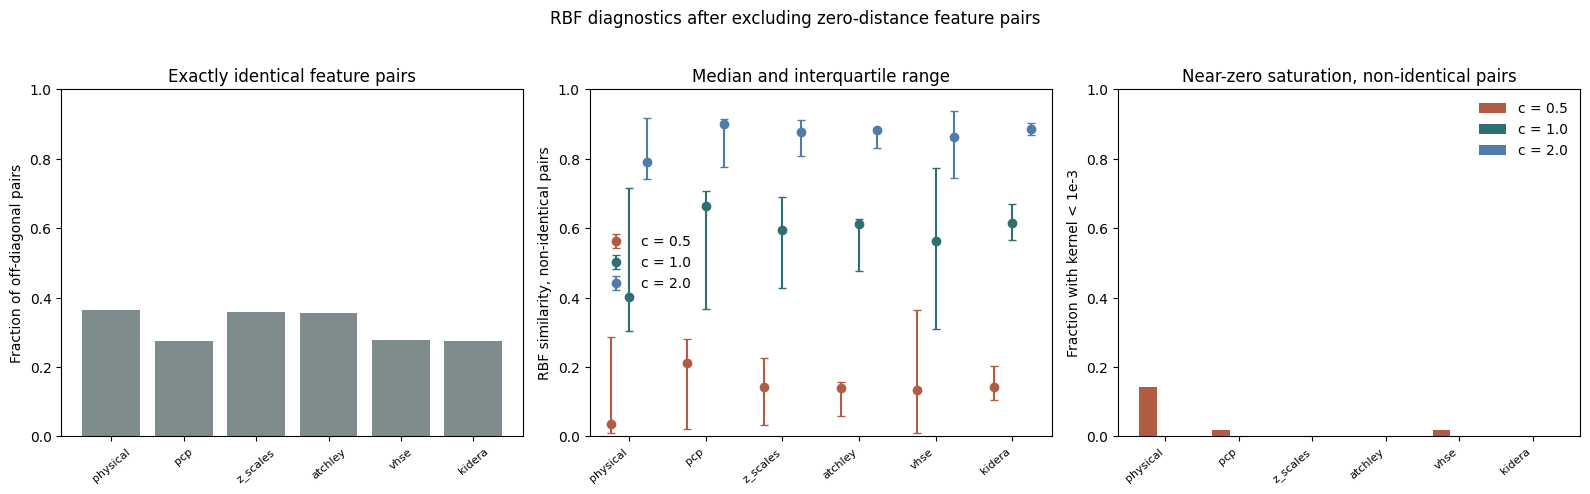

,source,lengthscale_multiplier,fraction_identical_pairs,median_kernel,q25_kernel,q75_kernel,fraction_near_zero,fraction_below_0p01,fraction_near_one
0,atchley,0.5,0.356723,0.139398,0.058417,0.155642,0.000000,0.007527,0.071764
1,atchley,1.0,0.356723,0.610865,0.477690,0.627095,0.000000,0.000000,0.078754
2,atchley,2.0,0.356723,0.884054,0.829764,0.889794,0.000000,0.000000,0.348695
3,kidera,0.5,0.276050,0.142400,0.103375,0.201469,0.000000,0.000000,0.146069
4,kidera,1.0,0.276050,0.614153,0.566994,0.668412,0.000000,0.000000,0.146069
5,kidera,2.0,0.276050,0.885244,0.867747,0.904061,0.000000,0.000000,0.225967
6,pcp,0.5,0.275210,0.210203,0.020491,0.280917,0.017722,0.167457,0.136683
7,pcp,1.0,0.275210,0.663158,0.366488,0.707329,0.000000,0.000000,0.137756
8,pcp,2.0,0.275210,0.901182,0.776403,0.915316,0.000000,0.000000,0.460773
9,physical,0.5,0.363025,0.035856,0.009479,0.286441,0.141804,0.313013,0.084360


In [32]:
# Aggregate across position components for a compact representation-level view.
nonidentical_source_summary = (
    nonidentical_kernel_summary
    .groupby(["source", "lengthscale_multiplier"], as_index=False)
    .agg(
        fraction_identical_pairs=("fraction_identical_pairs", "mean"),
        median_kernel=("kernel_median_nonidentical", "median"),
        q25_kernel=("kernel_q25_nonidentical", "median"),
        q75_kernel=("kernel_q75_nonidentical", "median"),
        fraction_near_zero=("fraction_nonidentical_kernel_lt_1e-3", "mean"),
        fraction_below_0p01=("fraction_nonidentical_kernel_lt_0p01", "mean"),
        fraction_near_one=("fraction_nonidentical_kernel_gt_0p9", "mean"),
    )
)

source_order = list(diagnostic_plot["source"])
multiplier_order = list(KERNEL_DIAGNOSTIC_MULTIPLIERS)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))

# Panel A: explicitly show how much of the original >0.9 fraction is explained
# by exact feature duplicates. This quantity does not depend on the length scale.
identical_plot = (
    nonidentical_source_summary
    .query("lengthscale_multiplier == 1.0")
    .set_index("source")
    .reindex(source_order)
)
axes[0].bar(source_order, identical_plot["fraction_identical_pairs"], color="#7f8c8d")
axes[0].set_ylim(0, 1)
axes[0].set_ylabel("Fraction of off-diagonal pairs")
axes[0].set_title("Exactly identical feature pairs")
axes[0].tick_params(axis="x", rotation=40, labelsize=8)

# Panel B: median and interquartile kernel similarity after zero-distance pairs
# have been removed.
colors = {0.5: "#b35c44", 1.0: "#2f6f73", 2.0: "#4f7cac"}
x = np.arange(len(source_order))
for offset, multiplier in zip((-0.24, 0.0, 0.24), multiplier_order):
    subset = (
        nonidentical_source_summary
        .query("lengthscale_multiplier == @multiplier")
        .set_index("source")
        .reindex(source_order)
    )
    median = subset["median_kernel"].to_numpy()
    lower = median - subset["q25_kernel"].to_numpy()
    upper = subset["q75_kernel"].to_numpy() - median
    axes[1].errorbar(
        x + offset, median, yerr=np.vstack([lower, upper]), fmt="o",
        color=colors[multiplier], capsize=3, label=f"c = {multiplier}",
    )
axes[1].set_xticks(x, source_order, rotation=40, ha="right", fontsize=8)
axes[1].set_ylim(0, 1)
axes[1].set_ylabel("RBF similarity, non-identical pairs")
axes[1].set_title("Median and interquartile range")
axes[1].legend(frameon=False)

# Panel C: true saturation after identical pairs have been excluded.
width = 0.24
for offset, multiplier in zip((-width, 0.0, width), multiplier_order):
    subset = (
        nonidentical_source_summary
        .query("lengthscale_multiplier == @multiplier")
        .set_index("source")
        .reindex(source_order)
    )
    axes[2].bar(
        x + offset, subset["fraction_near_zero"], width,
        color=colors[multiplier], label=f"c = {multiplier}",
    )
axes[2].set_xticks(x, source_order, rotation=40, ha="right", fontsize=8)
axes[2].set_ylim(0, 1)
axes[2].set_ylabel("Fraction with kernel < 1e-3")
axes[2].set_title("Near-zero saturation, non-identical pairs")
axes[2].legend(frameon=False)

fig.suptitle("RBF diagnostics after excluding zero-distance feature pairs", y=1.02)
fig.tight_layout()
fig.savefig(
    OUTPUT_DIR / "nonidentical_pair_kernel_diagnostics.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

display(nonidentical_source_summary)
nonidentical_source_summary.to_csv(
    OUTPUT_DIR / "nonidentical_pair_kernel_diagnostics_by_source.csv", index=False
)


In [33]:
# Scientific guardrails for the refined diagnostic.
assert not nonidentical_kernel_summary.empty
assert (nonidentical_kernel_summary["n_nonidentical_pairs"] > 0).all()
assert nonidentical_kernel_summary["fraction_identical_pairs"].between(0, 1).all()
for column in [
    "kernel_q05_nonidentical", "kernel_q25_nonidentical",
    "kernel_median_nonidentical", "kernel_q75_nonidentical",
    "kernel_q95_nonidentical",
]:
    assert nonidentical_kernel_summary[column].between(0, 1).all()
assert (
    nonidentical_kernel_summary["kernel_q05_nonidentical"]
    <= nonidentical_kernel_summary["kernel_q25_nonidentical"]
).all()
assert (
    nonidentical_kernel_summary["kernel_q25_nonidentical"]
    <= nonidentical_kernel_summary["kernel_median_nonidentical"]
).all()
assert (
    nonidentical_kernel_summary["kernel_median_nonidentical"]
    <= nonidentical_kernel_summary["kernel_q75_nonidentical"]
).all()
assert (
    nonidentical_kernel_summary["kernel_q75_nonidentical"]
    <= nonidentical_kernel_summary["kernel_q95_nonidentical"]
).all()

# Increasing the length scale must monotonically increase RBF similarity for
# every non-zero distance. Test this at the aggregated source level.
median_pivot = nonidentical_source_summary.pivot(
    index="source", columns="lengthscale_multiplier", values="median_kernel"
)
assert (median_pivot[0.5] <= median_pivot[1.0]).all()
assert (median_pivot[1.0] <= median_pivot[2.0]).all()
print("Non-identical-pair kernel diagnostics: all checks passed.")


Non-identical-pair kernel diagnostics: all checks passed.


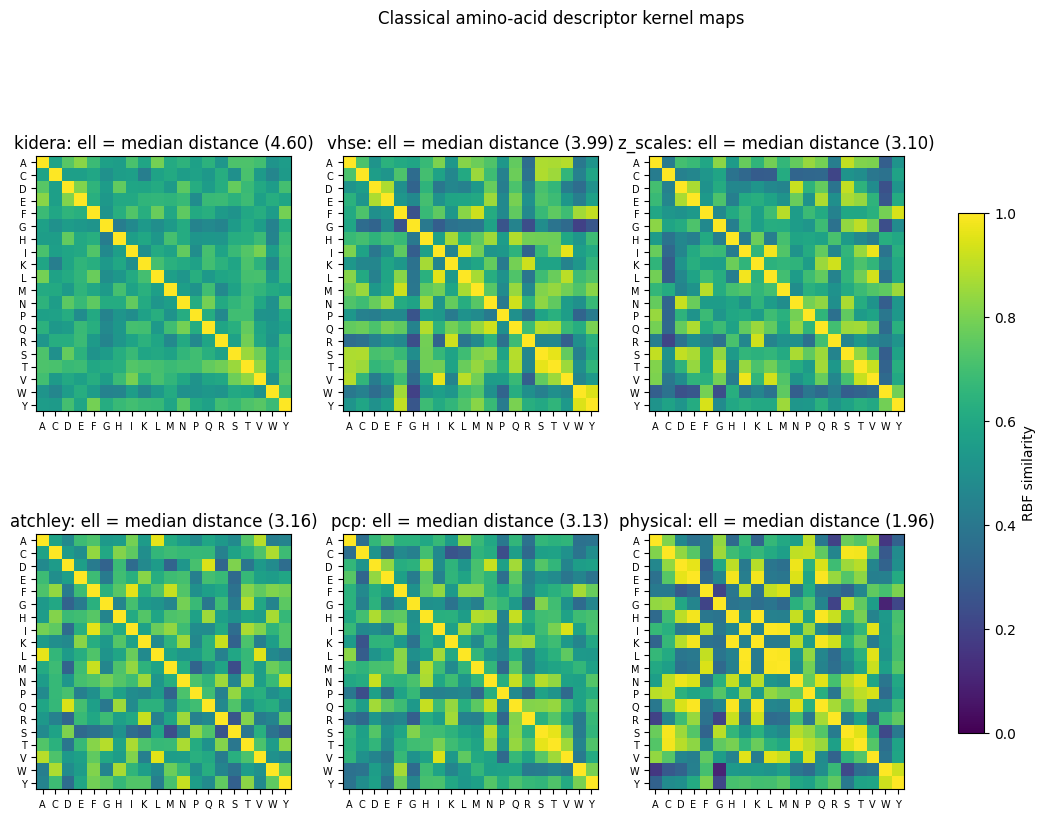

In [34]:
# Plot 2: amino-acid similarity maps for classical descriptors.
# These maps expose whether a descriptor family creates meaningful graded
# similarities or collapses to an almost identity-like kernel.
classical_sources = [diagnostic_sources[name] for name in CLASSICAL_DESCRIPTOR_NAMES]
n_cols = 3
n_rows = int(np.ceil(len(classical_sources) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4.5 * n_rows), squeeze=False)

for ax, source in zip(axes.ravel(), classical_sources):
    X = source.scaled_table.loc[list(CANONICAL_AA)].to_numpy(dtype=float)
    aa_scale = robust_distance_scale({"aa": X})
    K_aa = rbf_kernel_from_descriptors(X, lengthscale=aa_scale)
    image_handle = ax.imshow(K_aa, vmin=0, vmax=1, cmap="viridis")
    ax.set_xticks(range(len(CANONICAL_AA)), CANONICAL_AA, fontsize=7)
    ax.set_yticks(range(len(CANONICAL_AA)), CANONICAL_AA, fontsize=7)
    ax.set_title(f"{source.name}: ell = median distance ({aa_scale:.2f})")

for ax in axes.ravel()[len(classical_sources):]:
    ax.axis("off")

fig.colorbar(image_handle, ax=axes.ravel().tolist(), shrink=0.75, label="RBF similarity")
fig.suptitle("Classical amino-acid descriptor kernel maps", y=1.01)
fig.savefig(OUTPUT_DIR / "classical_descriptor_kernel_maps.png", dpi=300, bbox_inches="tight")
plt.show()


### Interpretation guardrail

For static descriptors, the feature at position (p) depends only on the amino
acid at (p), so the additive and pairwise ANOVA components retain a clean
statistical interpretation. For ESM-2 and METL, a target-position embedding is
contextual and may change when another position is mutated. Their position
kernels can therefore already contain cross-position information. Such models
remain valid predictors, but their ANOVA terms must not be interpreted as a
strict decomposition into pure main effects and pure pairwise epistasis.


## Nested LOOCV model comparison

Each held-out variant is predicted after selecting hyperparameters by
inner LOOCV on the outer training set only. This makes the additive vs.
epistatic comparison much less optimistic than selecting one best
non-nested grid result.

In [35]:
def fit_and_predict_one_fold(df_train, df_test, source, lengthscale, sigma_main, sigma_epi, sigma_noise):
    train_pockets = df_train["pocket"].tolist()
    test_pockets = df_test["pocket"].tolist()

    if getattr(source, "representation", None) == "global_delta":
        X_train = source.feature_matrix(train_pockets)
        X_test = source.feature_matrix(test_pockets)
        K_train = float(sigma_main) ** 2 * rbf_kernel_from_descriptors(
            X_train,
            lengthscale=lengthscale,
        )
        K_test_train = float(sigma_main) ** 2 * rbf_kernel_from_descriptors(
            X_test,
            X2=X_train,
            lengthscale=lengthscale,
        )
        K_test_diag = np.full(len(df_test), float(sigma_main) ** 2)
    else:
        train_arrays = pockets_to_position_descriptor_arrays(train_pockets, source)
        train_kernels = build_position_kernels(train_arrays, lengthscales=lengthscale)
        K_train, _, _ = build_total_anova_kernel(
            train_kernels,
            sigma_main=sigma_main,
            sigma_epi=sigma_epi,
        )
        K_test_train = build_total_cross_kernel(
            train_pockets=train_pockets,
            test_pockets=test_pockets,
            source=source,
            lengthscales=lengthscale,
            sigma_main=sigma_main,
            sigma_epi=sigma_epi,
        )
        K_test_diag = np.full(
            len(df_test),
            float(sigma_main) ** 2 + float(sigma_epi) ** 2,
        )

    gp_fit = fit_gp_from_kernel(
        K_train,
        y=df_train["activity_pa6"].to_numpy(dtype=float),
        sem=df_train["activity_sem_for_gp"].to_numpy(dtype=float),
        sigma_noise=sigma_noise,
    )
    return gp_predict_from_fit(gp_fit, K_test_train, K_test_diag)


def loocv_anova_gp(df_eval, source, lengthscale, sigma_main, sigma_epi, sigma_noise, label="model"):
    rows = []
    df_eval = df_eval.reset_index(drop=True)
    for test_idx in range(len(df_eval)):
        df_test = df_eval.iloc[[test_idx]].copy()
        df_train = df_eval.drop(index=test_idx).copy()
        pred = fit_and_predict_one_fold(df_train, df_test, source, lengthscale, sigma_main, sigma_epi, sigma_noise)
        observed = float(df_test["activity_pa6"].iloc[0])
        predicted = float(pred["mean"][0])
        rows.append({
            "model": label,
            "variant_id": df_test["variant_id"].iloc[0],
            "mutations": df_test["mutations"].iloc[0],
            "mutation_signature": df_test["mutation_signature"].iloc[0],
            "mutation_order": int(df_test["mutation_order"].iloc[0]),
            "observed": observed,
            "predicted": predicted,
            "predicted_std_latent": float(pred["std_latent"][0]),
            "predicted_std_observed": float(pred["std_observed"][0]),
            "abs_error": abs(observed - predicted),
            "lengthscale": lengthscale,
            "sigma_main": sigma_main,
            "sigma_epi": sigma_epi,
            "sigma_noise": sigma_noise,
        })
    result = pd.DataFrame(rows)
    metrics = regression_metrics(result["observed"], result["predicted"], result["predicted_std_observed"])
    return result, metrics


def evaluate_grid_loocv(df_eval, source, grid, label="model"):
    rows = []
    for params in grid:
        _, metrics = loocv_anova_gp(df_eval, source=source, label=label, **params)
        rows.append({**params, **metrics})
    return pd.DataFrame(rows).sort_values(["mae", "rmse"]).reset_index(drop=True)


def make_param_grid(model_type):
    lengthscale_values = (0.2, 0.5, 1.0)
    sigma_main_values = (0.5, 1.0)
    sigma_noise_values = (0.3, 0.5, 1.0)
    if model_type == "additive":
        sigma_epi_values = (0.0,)
    elif model_type == "epistatic":
        sigma_epi_values = (1.0, 2.0, 4.0)
    else:
        raise ValueError("model_type must be additive or epistatic")
    return [
        {
            "lengthscale": lengthscale,
            "sigma_main": sigma_main,
            "sigma_epi": sigma_epi,
            "sigma_noise": sigma_noise,
        }
        for lengthscale, sigma_main, sigma_epi, sigma_noise
        in product(lengthscale_values, sigma_main_values, sigma_epi_values, sigma_noise_values)
    ]


def select_hyperparameters_inner_loocv(df_train, source, model_type):
    grid_result = evaluate_grid_loocv(df_train, source=source, grid=make_param_grid(model_type), label=model_type)
    best = grid_result.iloc[0].to_dict()
    best_params = {key: best[key] for key in ["lengthscale", "sigma_main", "sigma_epi", "sigma_noise"]}
    return best_params, grid_result


def nested_loocv_model_comparison(df_eval, source, model_types=("additive", "epistatic")):
    df_eval = df_eval.reset_index(drop=True)
    rows = []
    inner_grids = {}
    for outer_idx in range(len(df_eval)):
        df_test = df_eval.iloc[[outer_idx]].copy()
        df_train = df_eval.drop(index=outer_idx).copy()
        variant_id = df_test["variant_id"].iloc[0]
        for model_type in model_types:
            best_params, inner_grid = select_hyperparameters_inner_loocv(df_train, source=source, model_type=model_type)
            inner_grids[(variant_id, model_type)] = inner_grid
            pred = fit_and_predict_one_fold(df_train, df_test, source=source, **best_params)
            observed = float(df_test["activity_pa6"].iloc[0])
            predicted = float(pred["mean"][0])
            rows.append({
                "model": model_type,
                "variant_id": variant_id,
                "mutations": df_test["mutations"].iloc[0],
                "mutation_signature": df_test["mutation_signature"].iloc[0],
                "mutation_order": int(df_test["mutation_order"].iloc[0]),
                "observed": observed,
                "predicted": predicted,
                "predicted_std_latent": float(pred["std_latent"][0]),
                "predicted_std_observed": float(pred["std_observed"][0]),
                "abs_error": abs(observed - predicted),
                **{f"selected_{key}": value for key, value in best_params.items()},
                "inner_mae": float(inner_grid.iloc[0]["mae"]),
            })
        print(f"{outer_idx + 1:02d}/{len(df_eval)} {variant_id}")
    result = pd.DataFrame(rows)
    metrics = []
    for model, group in result.groupby("model"):
        metrics.append({
            "model": model,
            **regression_metrics(group["observed"], group["predicted"], group["predicted_std_observed"]),
        })
    return result, pd.DataFrame(metrics).sort_values("mae"), inner_grids

In [36]:
nested_result_df, nested_metrics_df, nested_inner_grids = nested_loocv_model_comparison(
    df_core,
    source=descriptor_source,
    model_types=("additive", "epistatic"),
)

nested_result_df.to_csv(OUTPUT_DIR / "nested_loocv_predictions_additive_vs_epistatic.csv", index=False)
nested_metrics_df.to_csv(OUTPUT_DIR / "nested_loocv_metrics_additive_vs_epistatic.csv", index=False)

display(nested_metrics_df)
display(nested_result_df.sort_values(["model", "abs_error"], ascending=[True, False]).head(20))

01/35 WT
02/35 D99G
03/35 D99V
04/35 D99R
05/35 F134W
06/35 D304M
07/35 D304E
08/35 D304Q
09/35 D304V
10/35 D304W
11/35 D304R
12/35 D304L
13/35 R330A
14/35 R330Q
15/35 F134W_D304M
16/35 F134W_D304L
17/35 F134W_D304I
18/35 F134W_D304R
19/35 F134W_D304E
20/35 F134W_D304S
21/35 F134W_D304V
22/35 D99R_D304M
23/35 D99R_F134W
24/35 D99R_F134W_R330A
25/35 D99R_F134W_D304M
26/35 D99G_F134W_D304M
27/35 D99V_F134W_D304M
28/35 F134W_D304M_R330A
29/35 F134W_D304M_R330Q
30/35 D99R_F134W_D304M_R330A
31/35 D99G_F134W_D304M_R330A
32/35 D99V_F134W_D304M_R330A
33/35 D99R_F134W_D304M_R330Q
34/35 D99G_F134W_D304M_R330Q
35/35 D99V_F134W_D304M_R330Q


,model,mae,rmse,r2,pearson,spearman,nlpd_observed
1,epistatic,49.901150,59.952098,0.664780,0.815579,0.814483,6.304780
0,additive,61.809359,73.906217,0.490572,0.700590,0.727782,5.858437


,model,variant_id,mutations,mutation_signature,mutation_order,observed,predicted,predicted_std_latent,predicted_std_observed,abs_error,selected_lengthscale,selected_sigma_main,selected_sigma_epi,selected_sigma_noise,inner_mae
54,additive,F134W_D304M_R330A,F134W;D304M;R330A,134+304+330,3,520.000000,339.123726,22.878943,52.482955,180.876274,0.2,0.5,0.0,0.5,55.142295
24,additive,R330A,R330A,330,1,147.000000,291.478995,35.178285,63.349970,144.478995,0.2,1.0,0.0,0.5,54.032914
28,additive,F134W_D304M,F134W;D304M,134+304,2,409.666667,279.805581,19.861809,54.887481,129.861085,0.2,0.5,0.0,0.5,54.810985
46,additive,D99R_F134W_R330A,D99R;F134W;R330A,99+134+330,3,406.000000,286.992559,29.361628,59.074993,119.007441,0.2,0.5,0.0,0.5,57.315275
30,additive,F134W_D304L,F134W;D304L,134+304,2,370.333333,253.577796,57.119178,118.758491,116.755538,0.2,1.0,0.0,1.0,55.233454
58,additive,D99R_F134W_D304M_R330A,D99R;F134W;D304M;R330A,99+134+304+330,4,296.000000,399.393382,17.962669,36.568895,103.393382,0.2,0.5,0.0,0.3,56.991879
68,additive,D99V_F134W_D304M_R330Q,D99V;F134W;D304M;R330Q,99+134+304+330,4,205.000000,297.208353,29.715319,60.963019,92.208353,0.2,0.5,0.0,0.5,58.104124
0,additive,WT,NaN,WT,0,77.666667,165.124757,19.496421,54.935370,87.458091,0.2,0.5,0.0,0.5,58.535606
56,additive,F134W_D304M_R330Q,F134W;D304M;R330Q,134+304+330,3,372.000000,287.910280,25.583889,57.977297,84.089720,0.2,0.5,0.0,0.5,56.037890
52,additive,D99V_F134W_D304M,D99V;F134W;D304M,99+134+304,3,201.000000,283.229767,26.904388,59.624115,82.229767,0.2,0.5,0.0,0.5,57.777632


## Paired additive-vs-epistatic error comparison

Errors are paired by held-out variant. The Wilcoxon test is included as
a descriptive diagnostic, not as definitive proof.

In [37]:
paired_errors = nested_result_df.pivot(index="variant_id", columns="model", values="abs_error")
paired_errors["error_reduction_epistatic_vs_additive"] = paired_errors["additive"] - paired_errors["epistatic"]
paired_errors = paired_errors.sort_values("error_reduction_epistatic_vs_additive", ascending=False)

try:
    wilcoxon_result = wilcoxon(
        paired_errors["additive"],
        paired_errors["epistatic"],
        alternative="greater",
        zero_method="wilcox",
    )
except ValueError as exc:
    wilcoxon_result = exc

print("Mean paired error reduction:", paired_errors["error_reduction_epistatic_vs_additive"].mean())
print("Median paired error reduction:", paired_errors["error_reduction_epistatic_vs_additive"].median())
print("Wilcoxon additive error > epistatic error:", wilcoxon_result)

display(paired_errors)
paired_errors.to_csv(OUTPUT_DIR / "paired_error_reduction_epistatic_vs_additive.csv")

Mean paired error reduction: 11.908209044247467
Median paired error reduction: 6.392268615618377
Wilcoxon additive error > epistatic error: WilcoxonResult(statistic=422.0, pvalue=0.040519967064028606)


model,additive,epistatic,error_reduction_epistatic_vs_additive
variant_id,,,
F134W_D304M_R330A,180.876274,64.253360,116.622914
WT,87.458091,22.454659,65.003432
F134W_D304M,129.861085,66.789008,63.072077
F134W_D304M_R330Q,84.089720,25.935652,58.154068
R330A,144.478995,97.581355,46.897640
D99V_F134W_D304M_R330Q,92.208353,51.238202,40.970151
D99V,65.512670,24.699690,40.812980
D99R,68.483792,35.551443,32.932349
D99G_F134W_D304M_R330Q,44.221697,11.802234,32.419463


## Error structure and uncertainty calibration

A useful GP should not only rank variants; its posterior uncertainty
should also be informative. Coverage, NLPD and uncertainty-error
correlation are therefore reported explicitly.

In [38]:
best_primary_model = nested_metrics_df.sort_values("mae").iloc[0]["model"]
primary_predictions = nested_result_df[nested_result_df["model"] == best_primary_model].copy()
print("Primary nested model selected by MAE:", best_primary_model)


def coverage_table(pred_df, std_col="predicted_std_observed"):
    z_for_interval = {"50%": 0.67448975, "68%": 1.0, "90%": 1.64485363, "95%": 1.95996398}
    err = np.abs(pred_df["observed"] - pred_df["predicted"])
    rows = []
    for label, z in z_for_interval.items():
        rows.append({
            "interval": label,
            "nominal_z": z,
            "empirical_coverage": float((err <= z * pred_df[std_col]).mean()),
        })
    return pd.DataFrame(rows)


calibration = coverage_table(primary_predictions)
uncertainty_error_spearman = primary_predictions["predicted_std_observed"].corr(primary_predictions["abs_error"], method="spearman")

print("Spearman predicted uncertainty vs absolute error:", uncertainty_error_spearman)
display(calibration)
calibration.to_csv(OUTPUT_DIR / "uncertainty_coverage_primary_model.csv", index=False)

error_by_order = (
    primary_predictions
    .groupby("mutation_order")
    .agg(
        n=("abs_error", "size"),
        mae=("abs_error", "mean"),
        median_abs_error=("abs_error", "median"),
        mean_predicted_std=("predicted_std_observed", "mean"),
    )
    .reset_index()
)
display(error_by_order)
error_by_order.to_csv(OUTPUT_DIR / "error_by_mutation_order_primary_model.csv", index=False)

Primary nested model selected by MAE: epistatic
Spearman predicted uncertainty vs absolute error: -0.16694677871148458


,interval,nominal_z,empirical_coverage
0,50%,0.674490,0.971429
1,68%,1.000000,1.000000
2,90%,1.644854,1.000000
3,95%,1.959964,1.000000


,mutation_order,n,mae,median_abs_error,mean_predicted_std
0,0,1,22.454659,22.454659,68.525906
1,1,13,35.672524,28.133167,244.020274
2,2,9,60.414977,61.157617,239.971963
3,3,6,59.888378,51.756734,180.335286
4,4,6,59.546283,53.050037,209.901491


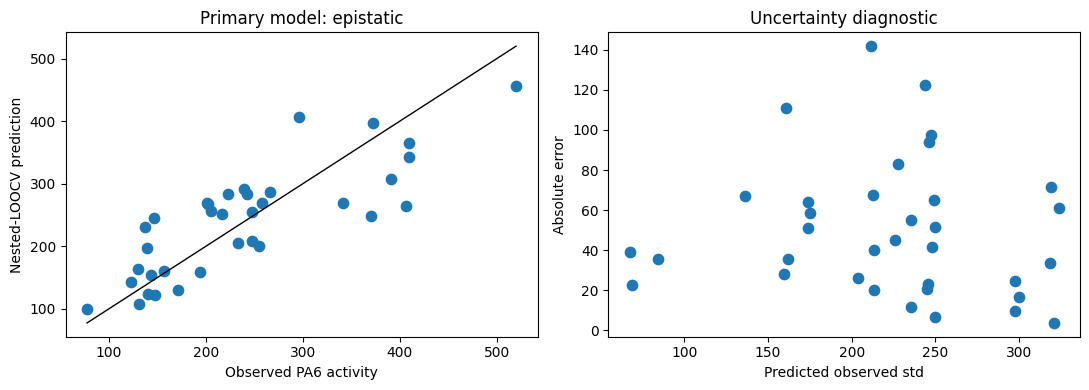

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].scatter(primary_predictions["observed"], primary_predictions["predicted"], s=55)
lo = min(primary_predictions["observed"].min(), primary_predictions["predicted"].min())
hi = max(primary_predictions["observed"].max(), primary_predictions["predicted"].max())
axes[0].plot([lo, hi], [lo, hi], color="black", linewidth=1)
axes[0].set_xlabel("Observed PA6 activity")
axes[0].set_ylabel("Nested-LOOCV prediction")
axes[0].set_title(f"Primary model: {best_primary_model}")

axes[1].scatter(primary_predictions["predicted_std_observed"], primary_predictions["abs_error"], s=55)
axes[1].set_xlabel("Predicted observed std")
axes[1].set_ylabel("Absolute error")
axes[1].set_title("Uncertainty diagnostic")

fig.tight_layout()
fig.savefig(OUTPUT_DIR / "primary_model_prediction_and_uncertainty.png", dpi=300, bbox_inches="tight")
plt.show()

## Exploratory family holdout

LOOCV mostly tests interpolation. This diagnostic asks what happens when
all variants containing a given target position are held out together.
It is explicitly exploratory because training sets become small and
chemically incomplete.

In [40]:
def select_full_data_params_for_model(df_eval, source, model_type):
    params, grid_result = select_hyperparameters_inner_loocv(df_eval, source=source, model_type=model_type)
    return params, grid_result


primary_params, primary_full_grid = select_full_data_params_for_model(df_core, descriptor_source, best_primary_model)
print("Exploratory full-data-selected params for family holdout:", primary_params)


def position_family_holdout(df_eval, source, params):
    rows = []
    for pos in POSITIONS:
        is_test = df_eval["mutation_positions"].apply(lambda s: pos in s)
        df_test = df_eval[is_test].copy()
        df_train = df_eval[~is_test].copy()
        if df_test.empty or len(df_train) < 5:
            continue
        pred = fit_and_predict_one_fold(df_train, df_test, source=source, **params)
        tmp = df_test[["variant_id", "mutations", "mutation_signature", "mutation_order", "activity_pa6"]].copy()
        tmp["heldout_position"] = pos
        tmp["observed"] = tmp["activity_pa6"]
        tmp["predicted"] = pred["mean"]
        tmp["predicted_std_observed"] = pred["std_observed"]
        tmp["abs_error"] = np.abs(tmp["observed"] - tmp["predicted"])
        rows.append(tmp.drop(columns=["activity_pa6"]))
    if not rows:
        return pd.DataFrame(), pd.DataFrame()
    result = pd.concat(rows, ignore_index=True)
    summary = (
        result.groupby("heldout_position")
        .agg(n=("abs_error", "size"), mae=("abs_error", "mean"), median_abs_error=("abs_error", "median"))
        .reset_index()
    )
    return result, summary


family_holdout_df, family_holdout_summary = position_family_holdout(df_core, descriptor_source, primary_params)
display(family_holdout_summary)
display(family_holdout_df.sort_values("abs_error", ascending=False).head(20))
family_holdout_df.to_csv(OUTPUT_DIR / "exploratory_position_family_holdout_predictions.csv", index=False)
family_holdout_summary.to_csv(OUTPUT_DIR / "exploratory_position_family_holdout_summary.csv", index=False)

Exploratory full-data-selected params for family holdout: {'lengthscale': 0.2, 'sigma_main': 0.5, 'sigma_epi': 4.0, 'sigma_noise': 0.5}


,heldout_position,n,mae,median_abs_error
0,99,15,52.619158,34.731433
1,134,21,149.665086,143.379435
2,304,26,72.724401,48.207917
3,330,11,83.858830,43.693677


,variant_id,mutations,mutation_signature,mutation_order,heldout_position,observed,predicted,predicted_std_observed,abs_error
28,F134W_D304M_R330A,F134W;D304M;R330A,134+304+330,3,134,520.000000,215.587239,135.948270,304.412761
54,F134W_D304M_R330A,F134W;D304M;R330A,134+304+330,3,304,520.000000,256.675069,355.572006,263.324931
31,D99G_F134W_D304M_R330A,D99G;F134W;D304M;R330A,99+134+304+330,4,134,410.000000,148.786865,144.611255,261.213135
32,D99V_F134W_D304M_R330A,D99V;F134W;D304M;R330A,99+134+304+330,4,134,391.000000,148.815061,144.611238,242.184939
17,F134W_D304L,F134W;D304L,134+304,2,134,370.333333,133.033289,122.777866,237.300045
43,F134W_D304M,F134W;D304M,134+304,2,304,409.666667,204.371867,326.605129,205.294800
18,F134W_D304I,F134W;D304I,134+304,2,134,341.333333,136.169989,139.214639,205.163345
16,F134W_D304M,F134W;D304M,134+304,2,134,409.666667,207.198234,122.037692,202.468433
24,D99R_F134W_R330A,D99R;F134W;R330A,99+134+330,3,134,406.000000,204.327378,136.215710,201.672622
69,D99V_F134W_D304M_R330A,D99V;F134W;D304M;R330A,99+134+304+330,4,330,391.000000,189.656391,275.199435,201.343609


## Exploratory descriptor-set sensitivity

This checks whether the qualitative epistasis conclusion is highly
dependent on one descriptor family. It is supplemental because descriptor
choice itself is another model-selection layer.

In [41]:
descriptor_sensitivity_rows = []


def compact_grid_for_sensitivity(model_type):
    lengthscale_values = (0.2, 0.5, 1.0)
    sigma_main_values = (0.5, 1.0)
    sigma_noise_values = (0.5, 1.0)
    sigma_epi_values = (0.0,) if model_type in {"additive", "global_rbf"} else (1.0, 2.0, 4.0)
    return [
        {"lengthscale": ls, "sigma_main": sm, "sigma_epi": se, "sigma_noise": sn}
        for ls, sm, se, sn in product(lengthscale_values, sigma_main_values, sigma_epi_values, sigma_noise_values)
    ]


for source_name in AVAILABLE_FEATURE_SOURCES:
    source = make_feature_source(source_name)
    model_types = (
        ("global_rbf",)
        if source_name == PROTEIN_LLM_GLOBAL_DELTA_VARIANT
        else ("additive", "epistatic")
    )
    for model_type in model_types:
        grid = compact_grid_for_sensitivity(model_type)
        grid_result = evaluate_grid_loocv(df_core, source=source, grid=grid, label=model_type)
        best = grid_result.iloc[0].to_dict()
        descriptor_sensitivity_rows.append({
            "descriptor_set": source_name,
            "descriptor_description": source.description,
            "model": model_type,
            **best,
        })

sensitivity_df = pd.DataFrame(descriptor_sensitivity_rows).sort_values(["mae", "rmse"]).reset_index(drop=True)
display(sensitivity_df)
sensitivity_df.to_csv(OUTPUT_DIR / "exploratory_descriptor_sensitivity.csv", index=False)

,descriptor_set,descriptor_description,model,lengthscale,sigma_main,sigma_epi,sigma_noise,mae,rmse,r2,pearson,spearman,nlpd_observed
0,physical,Two physical descriptors; PD1 relates to volum...,epistatic,0.2,0.5,4.0,0.5,37.506517,48.713356,0.778682,0.883089,0.863086,6.238166
1,z_scales,Z-scales; compact amino-acid physicochemical d...,epistatic,0.5,0.5,4.0,0.5,42.519271,54.373220,0.724265,0.851467,0.841796,6.293260
2,vhse,"VHSE scales; hydrophobic, steric and electroni...",epistatic,0.5,0.5,4.0,0.5,44.075087,56.714912,0.700004,0.837230,0.817004,6.305400
3,kidera,Kidera factors; 10-dimensional physicochemical...,epistatic,0.2,0.5,4.0,0.5,44.097570,56.782335,0.699290,0.836812,0.821206,6.306010
4,pcp,Physical-chemical property descriptors from pe...,epistatic,0.2,0.5,4.0,0.5,44.097572,56.782338,0.699290,0.836812,0.821206,6.306010
5,atchley,Atchley factors; multidimensional amino-acid d...,epistatic,0.2,0.5,4.0,0.5,44.097667,56.782435,0.699289,0.836811,0.821206,6.306010
6,physical,Two physical descriptors; PD1 relates to volum...,additive,1.0,0.5,0.0,0.5,55.908704,68.494381,0.562447,0.759312,0.792773,5.722533
7,z_scales,Z-scales; compact amino-acid physicochemical d...,additive,0.2,0.5,0.0,0.5,58.550568,70.417780,0.537528,0.738595,0.777645,5.755953
8,kidera,Kidera factors; 10-dimensional physicochemical...,additive,0.2,0.5,0.0,0.5,58.556226,70.425100,0.537431,0.738521,0.777645,5.756073
9,vhse,"VHSE scales; hydrophobic, steric and electroni...",additive,0.2,0.5,0.0,0.5,58.556227,70.425100,0.537431,0.738521,0.777645,5.756073


## Final reporting guidance

Use the nested LOOCV table as the primary result. A conservative wording:

> A package-derived physicochemical ANOVA-GP suggests that pairwise
> pocket-position interaction terms improve retrospective PA6 activity
> prediction relative to an additive model. Because the dataset contains
> only 35 four-position variants and lacks an external prospective test
> set, the model should be interpreted as hypothesis-generating rather
> than as a calibrated predictor.

In [42]:
report_bundle = {
    "nested_metrics": nested_metrics_df,
    "paired_errors": paired_errors.reset_index(),
    "calibration": calibration,
    "error_by_order": error_by_order,
    "descriptor_sensitivity": sensitivity_df,
}

for name, table in report_bundle.items():
    out_file = OUTPUT_DIR / f"{name}.csv"
    table.to_csv(out_file, index=False)
    print(name, "->", out_file)

nested_metrics -> /rwthfs/rz/cluster/home/dwp46550/ba_nylon/results/anova_gp_reviewed/nested_metrics.csv
paired_errors -> /rwthfs/rz/cluster/home/dwp46550/ba_nylon/results/anova_gp_reviewed/paired_errors.csv
calibration -> /rwthfs/rz/cluster/home/dwp46550/ba_nylon/results/anova_gp_reviewed/calibration.csv
error_by_order -> /rwthfs/rz/cluster/home/dwp46550/ba_nylon/results/anova_gp_reviewed/error_by_order.csv
descriptor_sensitivity -> /rwthfs/rz/cluster/home/dwp46550/ba_nylon/results/anova_gp_reviewed/descriptor_sensitivity.csv


## Reviewer-hardening additions

The following cells implement additional controls requested after the
first reviewer-style evaluation:

- nested descriptor-family selection;
- strict position-family holdout with all model choices made on the
  training set only;
- simple baselines;
- an explicitly exploratory 3-way epistasis check;
- replicate-level bootstrap sensitivity.

Interpretation rule:

- nested descriptor/model selection and strict family holdout can be
  reported as validation diagnostics;
- 3-way epistasis and bootstrap sensitivity are exploratory support
  analyses and should not replace external validation.

### Leakage-safe hybrid Nested CV and marginal-likelihood optimization (v3)

Discrete scientific choices are evaluated by nested LOOCV, while continuous
GP parameters are fitted by bounded, regularized marginal likelihood. Inside
every inner and outer training fold:

1. features are computed for training and test sequences;
2. optional PCA is fitted only to the training features;
3. the median non-zero training distance defines the scale (m);
4. the actual RBF length scale is ℓ = c m;
5. lengthscale multiplier, kernel amplitudes and residual noise are optimized
   using multi-start regularized marginal likelihood;
6. descriptor source, PCA dimension and additive/epistatic family are selected
   from genuinely held-out inner predictions.

This prevents the held-out activity and held-out feature distribution from
affecting preprocessing, marginal-likelihood fitting or model selection. The
measured variant-specific SEM remains fixed; only additional residual noise is
optimized. Epistasis is weakly shrunk toward zero and must be supported by data.


In [ ]:
# Discrete scientific choices remain inside nested CV. Continuous GP
# hyperparameters are fitted by regularized marginal likelihood in every fold.
HARDENED_PCA_COMPONENTS = (5, 10)
MLL_N_STARTS = 8
MLL_INNER_N_STARTS = 3  # Runtime compromise; final outer fits use MLL_N_STARTS.
MLL_RANDOM_SEED = 20250308
MLL_MAXITER = 300
MLL_BOUNDS = {
    "lengthscale_multiplier": (0.25, 4.0),
    "sigma_main": (0.05, 4.0),
    "sigma_epi": (1e-3, 4.0),
    "sigma_noise": (0.03, 2.0),
}
MLL_LOG_PRIOR_SD = {
    "lengthscale_multiplier": 0.70,
    "sigma_main": 1.00,
    "sigma_noise": 1.00,
}
MLL_NOISE_PRIOR_CENTER = 0.30
MLL_EPI_SHRINKAGE_SCALE = 1.00

DESCRIPTOR_CACHE = {}


def get_descriptor_source(source_name):
    """Create each frozen feature source once and reuse its cached representation."""
    if source_name not in AVAILABLE_FEATURE_SOURCES:
        raise KeyError(f"Feature source is unavailable or disabled: {source_name}")
    if source_name not in DESCRIPTOR_CACHE:
        DESCRIPTOR_CACHE[source_name] = make_feature_source(source_name)
    return DESCRIPTOR_CACHE[source_name]


def fit_pca_train_only(X_train, X_test, requested_components):
    X_train = np.asarray(X_train, dtype=float)
    X_test = np.asarray(X_test, dtype=float)
    if requested_components is None:
        return X_train, X_test, None
    n_components = min(int(requested_components), X_train.shape[0] - 1, X_train.shape[1])
    if n_components < 1:
        raise ValueError("PCA requires at least one valid component.")
    reducer = PCA(n_components=n_components, svd_solver="full")
    X_train_reduced = reducer.fit_transform(X_train)
    X_test_reduced = reducer.transform(X_test)
    return X_train_reduced, X_test_reduced, reducer


def prepare_fold_features(train_pockets, test_pockets, source, pca_components=None):
    representation = getattr(source, "representation", None)
    if representation == "global_delta":
        train_raw = np.asarray(source.feature_matrix(train_pockets), dtype=float)
        test_raw = np.asarray(source.feature_matrix(test_pockets), dtype=float)
        train_reduced, test_reduced, reducer = fit_pca_train_only(
            train_raw, test_raw, pca_components
        )
        return {
            "kind": "global",
            "train": {"global": train_reduced},
            "test": {"global": test_reduced},
            "reducers": {"global": reducer},
        }

    train_raw = pockets_to_position_descriptor_arrays(train_pockets, source)
    test_raw = pockets_to_position_descriptor_arrays(test_pockets, source)
    train_out, test_out, reducers = {}, {}, {}
    for pos in POSITIONS:
        apply_pca = pca_components if is_learned_source_name(source.name) else None
        train_out[pos], test_out[pos], reducers[pos] = fit_pca_train_only(
            train_raw[pos], test_raw[pos], apply_pca
        )
    return {
        "kind": "position",
        "train": train_out,
        "test": test_out,
        "reducers": reducers,
    }


def kernels_from_prepared_features(prepared, lengthscale_multiplier, sigma_main, sigma_epi):
    distance_scale = robust_distance_scale(prepared["train"])
    lengthscale = float(lengthscale_multiplier) * distance_scale
    if not np.isfinite(lengthscale) or lengthscale <= 0:
        raise ValueError("Resolved length scale must be positive and finite.")

    if prepared["kind"] == "global":
        X_train = prepared["train"]["global"]
        X_test = prepared["test"]["global"]
        K_train = float(sigma_main) ** 2 * rbf_kernel_from_descriptors(
            X_train, lengthscale=lengthscale
        )
        K_test_train = float(sigma_main) ** 2 * rbf_kernel_from_descriptors(
            X_test, X2=X_train, lengthscale=lengthscale
        )
        K_test_diag = np.full(X_test.shape[0], float(sigma_main) ** 2)
    else:
        train_position_kernels = {
            pos: rbf_kernel_from_descriptors(X, lengthscale=lengthscale)
            for pos, X in prepared["train"].items()
        }
        cross_position_kernels = {
            pos: rbf_kernel_from_descriptors(
                prepared["test"][pos], X2=prepared["train"][pos], lengthscale=lengthscale
            )
            for pos in POSITIONS
        }
        K_train, _, _ = build_total_anova_kernel(
            train_position_kernels,
            sigma_main=sigma_main,
            sigma_epi=sigma_epi,
        )
        K_test_train = (
            float(sigma_main) ** 2 * build_main_kernel(cross_position_kernels)
            + float(sigma_epi) ** 2 * build_epistasis_kernel(cross_position_kernels)
        )
        K_test_diag = np.full(
            len(next(iter(prepared["test"].values()))),
            float(sigma_main) ** 2 + float(sigma_epi) ** 2,
        )

    return K_train, K_test_train, K_test_diag, distance_scale, lengthscale


def training_kernel_from_prepared(prepared, lengthscale_multiplier, sigma_main, sigma_epi):
    """Build a training kernel without touching held-out features."""
    distance_scale = robust_distance_scale(prepared["train"])
    lengthscale = float(lengthscale_multiplier) * distance_scale
    if prepared["kind"] == "global":
        X = prepared["train"]["global"]
        base_main = rbf_kernel_from_descriptors(X, lengthscale=lengthscale)
        base_epi = np.zeros_like(base_main)
    else:
        position_kernels = {
            pos: rbf_kernel_from_descriptors(X, lengthscale=lengthscale)
            for pos, X in prepared["train"].items()
        }
        base_main = build_main_kernel(position_kernels)
        base_epi = build_epistasis_kernel(position_kernels)
    K = float(sigma_main) ** 2 * base_main + float(sigma_epi) ** 2 * base_epi
    return K, distance_scale, lengthscale


def regularized_gp_objective(log_values, parameter_names, prepared, y, sem):
    """Negative log marginal likelihood plus weak scientific regularization."""
    params = dict(zip(parameter_names, np.exp(np.asarray(log_values, dtype=float))))
    sigma_epi = params.get("sigma_epi", 0.0)
    try:
        K, _, _ = training_kernel_from_prepared(
            prepared, params["lengthscale_multiplier"], params["sigma_main"], sigma_epi
        )
        y_scaled, _, y_std = standardize_target(y)
        sem_scaled = np.asarray(sem, dtype=float) / y_std
        diagonal = sem_scaled ** 2 + params["sigma_noise"] ** 2 + 1e-8
        K_y = (K + K.T) / 2 + np.diag(diagonal)
        L = np.linalg.cholesky(K_y)
        alpha = np.linalg.solve(L.T, np.linalg.solve(L, y_scaled))
        nll = (
            0.5 * float(y_scaled @ alpha)
            + float(np.log(np.diag(L)).sum())
            + 0.5 * len(y_scaled) * np.log(2.0 * np.pi)
        )
    except (ValueError, np.linalg.LinAlgError, FloatingPointError):
        return 1e30

    # Log-normal-style penalties keep weakly identified solutions away from
    # pathological length scales/amplitudes. Epistasis gets direct shrinkage
    # toward zero and must therefore be supported by the data.
    penalty = 0.0
    penalty += 0.5 * (np.log(params["lengthscale_multiplier"]) / MLL_LOG_PRIOR_SD["lengthscale_multiplier"]) ** 2
    penalty += 0.5 * (np.log(params["sigma_main"]) / MLL_LOG_PRIOR_SD["sigma_main"]) ** 2
    penalty += 0.5 * (
        np.log(params["sigma_noise"] / MLL_NOISE_PRIOR_CENTER)
        / MLL_LOG_PRIOR_SD["sigma_noise"]
    ) ** 2
    if "sigma_epi" in params:
        penalty += 0.5 * (params["sigma_epi"] / MLL_EPI_SHRINKAGE_SCALE) ** 2
    return float(nll + penalty)


def optimize_gp_hyperparameters(prepared, y, sem, model, n_starts=MLL_N_STARTS):
    """Fit continuous GP parameters using bounded multi-start MAP/MLL."""
    parameter_names = ["lengthscale_multiplier", "sigma_main"]
    if model == "epistatic":
        parameter_names.append("sigma_epi")
    parameter_names.append("sigma_noise")
    if model not in {"global_rbf", "additive", "epistatic"}:
        raise ValueError(f"Unknown model family: {model}")
    if model == "global_rbf" and prepared["kind"] != "global":
        raise ValueError("global_rbf requires a global representation")

    log_bounds = [tuple(np.log(MLL_BOUNDS[name])) for name in parameter_names]
    initial = {
        "lengthscale_multiplier": 1.0,
        "sigma_main": 1.0,
        "sigma_epi": 0.5,
        "sigma_noise": MLL_NOISE_PRIOR_CENTER,
    }
    starts = [np.log([initial[name] for name in parameter_names])]
    rng = np.random.default_rng(MLL_RANDOM_SEED + len(y) + len(parameter_names))
    for _ in range(max(int(n_starts) - 1, 0)):
        starts.append(np.asarray([rng.uniform(low, high) for low, high in log_bounds]))

    results = [
        minimize(
            regularized_gp_objective, start,
            args=(parameter_names, prepared, np.asarray(y, dtype=float), np.asarray(sem, dtype=float)),
            method="L-BFGS-B", bounds=log_bounds,
            options={"maxiter": MLL_MAXITER, "ftol": 1e-10},
        )
        for start in starts
    ]
    finite_results = [result for result in results if np.isfinite(result.fun)]
    if not finite_results:
        raise RuntimeError("All marginal-likelihood optimization starts failed.")
    best = min(finite_results, key=lambda result: result.fun)
    fitted = dict(zip(parameter_names, np.exp(best.x)))
    fitted.setdefault("sigma_epi", 0.0)

    boundary_hits = {}
    for name, value in fitted.items():
        if name not in MLL_BOUNDS or (name == "sigma_epi" and model != "epistatic"):
            continue
        low, high = MLL_BOUNDS[name]
        log_span = np.log(high) - np.log(low)
        boundary_hits[name] = bool(
            min(abs(np.log(value) - np.log(low)), abs(np.log(high) - np.log(value)))
            <= 0.02 * log_span
        )
    fitted.update({
        "regularized_neg_log_marginal_likelihood": float(best.fun),
        "optimizer_success": bool(best.success),
        "optimizer_message": str(best.message),
        "optimizer_iterations": int(best.nit),
        "successful_restarts": int(sum(result.success for result in finite_results)),
        "n_restarts": int(len(results)),
        "boundary_hits": boundary_hits,
        "any_boundary_hit": bool(any(boundary_hits.values())),
    })
    return fitted


def fit_and_predict_one_fold_hardened(
    df_train, df_test, source, setting, fitted_hyperparameters=None, n_starts=MLL_N_STARTS
):
    train_pockets = df_train["pocket"].tolist()
    test_pockets = df_test["pocket"].tolist()
    prepared = prepare_fold_features(
        train_pockets,
        test_pockets,
        source,
        pca_components=setting.get("pca_components"),
    )
    if fitted_hyperparameters is None:
        fitted_hyperparameters = optimize_gp_hyperparameters(
            prepared,
            y=df_train["activity_pa6"].to_numpy(dtype=float),
            sem=df_train["activity_sem_for_gp"].to_numpy(dtype=float),
            model=setting["model"], n_starts=n_starts,
        )
    K_train, K_test_train, K_test_diag, distance_scale, lengthscale = (
        kernels_from_prepared_features(
            prepared,
            lengthscale_multiplier=fitted_hyperparameters["lengthscale_multiplier"],
            sigma_main=fitted_hyperparameters["sigma_main"],
            sigma_epi=fitted_hyperparameters["sigma_epi"],
        )
    )
    gp_fit = fit_gp_from_kernel(
        K_train,
        y=df_train["activity_pa6"].to_numpy(dtype=float),
        sem=df_train["activity_sem_for_gp"].to_numpy(dtype=float),
        sigma_noise=fitted_hyperparameters["sigma_noise"],
    )
    prediction = gp_predict_from_fit(gp_fit, K_test_train, K_test_diag)
    prediction["training_distance_scale"] = distance_scale
    prediction["resolved_lengthscale"] = lengthscale
    prediction["min_train_kernel_eigenvalue"] = float(
        np.linalg.eigvalsh((K_train + K_train.T) / 2).min()
    )
    prediction["fitted_hyperparameters"] = dict(fitted_hyperparameters)
    return prediction


def source_pca_options(source_name):
    if not is_learned_source_name(source_name):
        return (None,)
    return (None,) + tuple(HARDENED_PCA_COMPONENTS)


def make_hardened_joint_grid():
    """Enumerate only discrete choices; continuous values are optimized per fold."""
    rows = []
    for source_name in AVAILABLE_FEATURE_SOURCES:
        source = get_descriptor_source(source_name)
        is_global = getattr(source, "representation", None) == "global_delta"
        model_specs = ("global_rbf",) if is_global else ("additive", "epistatic")
        for pca_components in source_pca_options(source_name):
            for model in model_specs:
                rows.append({
                    "descriptor_set": source_name,
                    "model": model,
                    "pca_components": pca_components,
                })
    return rows


def evaluate_hardened_setting_loocv(df_subset, setting):
    df_subset = df_subset.reset_index(drop=True)
    source = get_descriptor_source(setting["descriptor_set"])
    observed, predicted, predicted_std, optimization_rows = [], [], [], []
    for test_idx in range(len(df_subset)):
        df_test = df_subset.iloc[[test_idx]]
        df_train = df_subset.drop(index=test_idx)
        pred = fit_and_predict_one_fold_hardened(
            df_train, df_test, source, setting, n_starts=MLL_INNER_N_STARTS
        )
        observed.append(float(df_test["activity_pa6"].iloc[0]))
        predicted.append(float(pred["mean"][0]))
        predicted_std.append(float(pred["std_observed"][0]))
        hp = pred["fitted_hyperparameters"]
        optimization_rows.append({
            "lengthscale_multiplier": hp["lengthscale_multiplier"],
            "sigma_main": hp["sigma_main"],
            "sigma_epi": hp["sigma_epi"],
            "sigma_noise": hp["sigma_noise"],
            "regularized_neg_log_marginal_likelihood": hp["regularized_neg_log_marginal_likelihood"],
            "optimizer_success": hp["optimizer_success"],
            "any_boundary_hit": hp["any_boundary_hit"],
        })
    metrics = regression_metrics(observed, predicted, predicted_std)
    optimization_df = pd.DataFrame(optimization_rows)
    for name in ["lengthscale_multiplier", "sigma_main", "sigma_epi", "sigma_noise"]:
        metrics[f"median_fitted_{name}"] = float(optimization_df[name].median())
    metrics["optimizer_success_fraction"] = float(optimization_df["optimizer_success"].mean())
    metrics["boundary_hit_fraction"] = float(optimization_df["any_boundary_hit"].mean())
    return metrics


def select_hardened_setting_inner_loocv(df_train, joint_grid):
    rows = []
    for setting in joint_grid:
        metrics = evaluate_hardened_setting_loocv(df_train, setting)
        rows.append({**setting, **metrics})
    # MAE selects the scientific model family; NLPD and RMSE provide
    # deterministic tie-breakers without changing the primary endpoint.
    grid_df = pd.DataFrame(rows).sort_values(
        ["mae", "nlpd_observed", "rmse"]
    ).reset_index(drop=True)
    setting_keys = ["descriptor_set", "model", "pca_components"]
    best_setting = {key: grid_df.iloc[0][key] for key in setting_keys}
    if pd.isna(best_setting["pca_components"]):
        best_setting["pca_components"] = None
    return best_setting, grid_df


def nested_loocv_hardened_feature_selection(df_eval, joint_grid):
    df_eval = df_eval.reset_index(drop=True)
    rows, inner_grids = [], {}
    for outer_idx in range(len(df_eval)):
        df_test = df_eval.iloc[[outer_idx]].copy()
        df_train = df_eval.drop(index=outer_idx).copy()
        variant_id = df_test["variant_id"].iloc[0]
        best_setting, inner_grid = select_hardened_setting_inner_loocv(df_train, joint_grid)
        inner_grids[variant_id] = inner_grid
        source = get_descriptor_source(best_setting["descriptor_set"])
        pred = fit_and_predict_one_fold_hardened(df_train, df_test, source, best_setting)
        hp = pred["fitted_hyperparameters"]
        observed = float(df_test["activity_pa6"].iloc[0])
        predicted = float(pred["mean"][0])
        rows.append({
            "variant_id": variant_id,
            "mutations": df_test["mutations"].iloc[0],
            "mutation_signature": df_test["mutation_signature"].iloc[0],
            "mutation_order": int(df_test["mutation_order"].iloc[0]),
            "observed": observed,
            "predicted": predicted,
            "predicted_std_latent": float(pred["std_latent"][0]),
            "predicted_std_observed": float(pred["std_observed"][0]),
            "abs_error": abs(observed - predicted),
            "training_distance_scale": pred["training_distance_scale"],
            "resolved_lengthscale": pred["resolved_lengthscale"],
            "min_train_kernel_eigenvalue": pred["min_train_kernel_eigenvalue"],
            **{f"selected_{key}": value for key, value in best_setting.items()},
            "fitted_lengthscale_multiplier": hp["lengthscale_multiplier"],
            "fitted_sigma_main": hp["sigma_main"],
            "fitted_sigma_epi": hp["sigma_epi"],
            "fitted_sigma_noise": hp["sigma_noise"],
            "regularized_neg_log_marginal_likelihood": hp["regularized_neg_log_marginal_likelihood"],
            "optimizer_success": hp["optimizer_success"],
            "optimizer_iterations": hp["optimizer_iterations"],
            "optimizer_successful_restarts": hp["successful_restarts"],
            "optimizer_any_boundary_hit": hp["any_boundary_hit"],
            "optimizer_boundary_hits": str(hp["boundary_hits"]),
            "inner_mae": float(inner_grid.iloc[0]["mae"]),
            "inner_nlpd_observed": float(inner_grid.iloc[0]["nlpd_observed"]),
        })
        print(
            f"{outer_idx + 1:02d}/{len(df_eval)} {variant_id}: "
            f"{best_setting['descriptor_set']} {best_setting['model']} "
            f"c={hp['lengthscale_multiplier']:.3g} PCA={best_setting['pca_components']}"
        )

    predictions = pd.DataFrame(rows)
    metrics = pd.DataFrame([{
        "analysis": "nested_feature_model_selection_with_regularized_mll",
        **regression_metrics(
            predictions["observed"],
            predictions["predicted"],
            predictions["predicted_std_observed"],
        ),
    }])
    selection_columns = [column for column in predictions if column.startswith("selected_")]
    selection_summary = (
        predictions[selection_columns]
        .value_counts(dropna=False)
        .reset_index(name="count")
    )
    return predictions, metrics, selection_summary, inner_grids


def run_mll_smoke_test():
    """Fail early before the expensive nested run if the optimizer is invalid."""
    smoke_df = df_core.iloc[:min(12, len(df_core))].copy()
    source = get_descriptor_source(PRIMARY_DESCRIPTOR_SET)
    prepared = prepare_fold_features(
        smoke_df["pocket"].tolist(), smoke_df.iloc[:1]["pocket"].tolist(), source
    )
    hp = optimize_gp_hyperparameters(
        prepared, smoke_df["activity_pa6"].to_numpy(dtype=float),
        smoke_df["activity_sem_for_gp"].to_numpy(dtype=float),
        model="epistatic", n_starts=2,
    )
    for name in ["lengthscale_multiplier", "sigma_main", "sigma_epi", "sigma_noise"]:
        low, high = MLL_BOUNDS[name]
        assert low <= hp[name] <= high
    K, _, _ = training_kernel_from_prepared(
        prepared, hp["lengthscale_multiplier"], hp["sigma_main"], hp["sigma_epi"]
    )
    assert np.linalg.eigvalsh((K + K.T) / 2).min() > -1e-8
    assert np.isfinite(hp["regularized_neg_log_marginal_likelihood"])
    return hp


mll_smoke_test = run_mll_smoke_test()
print("MLL smoke test passed:", {
    key: round(mll_smoke_test[key], 4)
    for key in ["lengthscale_multiplier", "sigma_main", "sigma_epi", "sigma_noise"]
})

hardened_joint_grid = make_hardened_joint_grid()
print("Discrete source/PCA/model candidates:", len(hardened_joint_grid))
print(f"MLL restarts: inner={MLL_INNER_N_STARTS}, final outer fit={MLL_N_STARTS}")

hardened_predictions, hardened_metrics, hardened_selection_summary, hardened_inner_grids = (
    nested_loocv_hardened_feature_selection(df_core, hardened_joint_grid)
)

display(hardened_metrics)
display(hardened_selection_summary)
display(hardened_predictions.sort_values("abs_error", ascending=False).head(15))

hardened_optimizer_summary = pd.DataFrame([{
    "n_outer_folds": len(hardened_predictions),
    "optimizer_success_fraction": float(hardened_predictions["optimizer_success"].mean()),
    "boundary_hit_fraction": float(hardened_predictions["optimizer_any_boundary_hit"].mean()),
    "median_lengthscale_multiplier": float(hardened_predictions["fitted_lengthscale_multiplier"].median()),
    "median_sigma_main": float(hardened_predictions["fitted_sigma_main"].median()),
    "median_sigma_epi": float(hardened_predictions["fitted_sigma_epi"].median()),
    "median_sigma_noise": float(hardened_predictions["fitted_sigma_noise"].median()),
}])
display(hardened_optimizer_summary)

fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharex=True)
parameter_panels = [
    ("fitted_lengthscale_multiplier", "Lengthscale multiplier c"),
    ("fitted_sigma_main", "Main-effect amplitude"),
    ("fitted_sigma_epi", "Epistasis amplitude"),
    ("fitted_sigma_noise", "Residual-noise amplitude"),
]
source_colors = {
    name: plt.cm.tab20(i % 20)
    for i, name in enumerate(sorted(hardened_predictions["selected_descriptor_set"].unique()))
}
for ax, (column, label) in zip(axes.ravel(), parameter_panels):
    for source_name, group in hardened_predictions.groupby("selected_descriptor_set"):
        ax.scatter(group.index, group[column], s=28, alpha=0.8,
                   color=source_colors[source_name], label=source_name)
    ax.set_ylabel(label)
    ax.grid(alpha=0.2)
axes[0, 0].axhline(MLL_BOUNDS["lengthscale_multiplier"][0], color="#b35c44", ls="--", lw=1)
axes[0, 0].axhline(MLL_BOUNDS["lengthscale_multiplier"][1], color="#b35c44", ls="--", lw=1)
axes[1, 0].set_xlabel("Outer LOOCV fold")
axes[1, 1].set_xlabel("Outer LOOCV fold")
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="center left", bbox_to_anchor=(1.0, 0.5), frameon=False)
fig.suptitle("Fold stability of marginal-likelihood hyperparameters")
fig.tight_layout(rect=(0, 0, 0.86, 0.96))
fig.savefig(OUTPUT_DIR / "mll_hyperparameter_fold_stability.png", dpi=300, bbox_inches="tight")
plt.show()

hardened_predictions.to_csv(OUTPUT_DIR / "nested_hardened_feature_predictions.csv", index=False)
hardened_metrics.to_csv(OUTPUT_DIR / "nested_hardened_feature_metrics.csv", index=False)
hardened_selection_summary.to_csv(OUTPUT_DIR / "nested_hardened_feature_selected_settings.csv", index=False)
hardened_optimizer_summary.to_csv(OUTPUT_DIR / "mll_optimizer_summary.csv", index=False)


### Scientific and numerical validation tests

These checks fail loudly when core assumptions are violated. They test data
integrity, descriptor standardization, fair source inclusion, kernel validity,
outer-fold prediction uniqueness, positive uncertainty and the absence of
test-derived distance scaling in the hardened fold function.


In [ ]:
def run_feature_hardening_checks():
    # Dataset and representation integrity.
    assert len(df_core) == df_core["variant_id"].nunique(), "Variant IDs must be unique."
    assert df_core["only_target_positions"].all(), "External mutations entered the core model."
    assert np.isfinite(df_core["activity_pa6"]).all(), "Activity contains non-finite values."
    assert np.isfinite(df_core["activity_sem_for_gp"]).all(), "SEM contains non-finite values."
    assert (df_core["activity_sem_for_gp"] >= 0).all(), "SEM must be non-negative."

    # Every classical baseline must remain available, even with learned sources enabled.
    assert set(CLASSICAL_DESCRIPTOR_NAMES).issubset(AVAILABLE_FEATURE_SOURCES)
    assert len(AVAILABLE_FEATURE_SOURCES) == len(set(AVAILABLE_FEATURE_SOURCES))

    # Classical descriptor tables must be complete, finite and standardized.
    for source_name in CLASSICAL_DESCRIPTOR_NAMES:
        source = get_descriptor_source(source_name)
        assert source.scaled_table.shape[0] == 20
        assert set(source.scaled_table.index) == set(CANONICAL_AA)
        values = source.scaled_table.to_numpy(dtype=float)
        assert np.isfinite(values).all()
        np.testing.assert_allclose(values.mean(axis=0), 0.0, atol=1e-10)
        np.testing.assert_allclose(values.std(axis=0, ddof=0), 1.0, atol=1e-10)

    # Kernel algebra must produce valid covariance matrices.
    sample_source = get_descriptor_source(PRIMARY_DESCRIPTOR_SET)
    arrays = pockets_to_position_descriptor_arrays(df_core["pocket"].tolist(), sample_source)
    scale = robust_distance_scale(arrays)
    position_kernel_check = build_position_kernels(arrays, lengthscales=scale)
    K_check, _, _ = build_total_anova_kernel(position_kernel_check, sigma_main=0.5, sigma_epi=2.0)
    np.testing.assert_allclose(K_check, K_check.T, atol=1e-10)
    assert np.linalg.eigvalsh((K_check + K_check.T) / 2).min() > -1e-8

    # The hardened outer result must contain exactly one prediction per variant.
    assert len(hardened_predictions) == len(df_core)
    assert hardened_predictions["variant_id"].is_unique
    assert np.isfinite(hardened_predictions["predicted"]).all()
    assert (hardened_predictions["predicted_std_observed"] > 0).all()
    assert (hardened_predictions["resolved_lengthscale"] > 0).all()
    assert (hardened_predictions["min_train_kernel_eigenvalue"] > -1e-8).all()
    for name in ["lengthscale_multiplier", "sigma_main", "sigma_noise"]:
        low, high = MLL_BOUNDS[name]
        assert hardened_predictions[f"fitted_{name}"].between(low, high).all()
    assert hardened_predictions["fitted_sigma_epi"].between(0, MLL_BOUNDS["sigma_epi"][1]).all()
    assert np.isfinite(hardened_predictions["regularized_neg_log_marginal_likelihood"]).all()

    # Direct leakage sentinel: changing only a test feature may change its prediction,
    # but cannot change the training-derived distance scale.
    df_train = df_core.iloc[:-1].copy()
    df_test = df_core.iloc[[-1]].copy()
    setting = {
        "descriptor_set": PRIMARY_DESCRIPTOR_SET,
        "model": "epistatic",
        "pca_components": None,
    }
    source = get_descriptor_source(PRIMARY_DESCRIPTOR_SET)
    pred_a = fit_and_predict_one_fold_hardened(df_train, df_test, source, setting)
    df_test_changed = df_test.copy()
    changed_pocket = dict(df_test_changed.iloc[0]["pocket"])
    changed_pocket[POSITIONS[0]] = next(
        aa for aa in CANONICAL_AA if aa != changed_pocket[POSITIONS[0]]
    )
    df_test_changed.at[df_test_changed.index[0], "pocket"] = changed_pocket
    pred_b = fit_and_predict_one_fold_hardened(df_train, df_test_changed, source, setting)
    np.testing.assert_allclose(
        pred_a["training_distance_scale"], pred_b["training_distance_scale"], atol=0, rtol=0
    )
    for name in ["lengthscale_multiplier", "sigma_main", "sigma_epi", "sigma_noise"]:
        np.testing.assert_allclose(
            pred_a["fitted_hyperparameters"][name],
            pred_b["fitted_hyperparameters"][name], atol=0, rtol=0
        )

    return pd.DataFrame({
        "check": [
            "data integrity", "classical baseline retention", "descriptor standardization",
            "kernel PSD", "outer prediction uniqueness", "positive uncertainty",
            "training-only distance scale and MLL hyperparameters",
        ],
        "status": ["PASS"] * 7,
    })


feature_hardening_test_results = run_feature_hardening_checks()
display(feature_hardening_test_results)
feature_hardening_test_results.to_csv(OUTPUT_DIR / "feature_hardening_test_results.csv", index=False)


In [ ]:
# Predictive diagnostics for the independently held-out outer predictions.
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

lo = min(hardened_predictions["observed"].min(), hardened_predictions["predicted"].min())
hi = max(hardened_predictions["observed"].max(), hardened_predictions["predicted"].max())
axes[0, 0].errorbar(
    hardened_predictions["observed"],
    hardened_predictions["predicted"],
    yerr=hardened_predictions["predicted_std_observed"],
    fmt="o", alpha=0.75, color="#2f6f73", ecolor="#9bb7b9", capsize=2,
)
axes[0, 0].plot([lo, hi], [lo, hi], "--", color="black", linewidth=1)
axes[0, 0].set_xlabel("Observed PA6 activity")
axes[0, 0].set_ylabel("Nested-LOOCV prediction")
axes[0, 0].set_title("Held-out predictions with observed-response SD")

axes[0, 1].scatter(
    hardened_predictions["predicted_std_observed"],
    hardened_predictions["abs_error"],
    c=hardened_predictions["mutation_order"], cmap="viridis", s=55,
)
axes[0, 1].set_xlabel("Predicted observed-response SD")
axes[0, 1].set_ylabel("Absolute error")
axes[0, 1].set_title("Does predicted uncertainty track error?")

selection_counts = hardened_predictions["selected_descriptor_set"].value_counts()
axes[1, 0].bar(selection_counts.index, selection_counts.values, color="#4f7cac")
axes[1, 0].set_ylabel("Outer folds selected")
axes[1, 0].set_title("Feature-source selection stability")
axes[1, 0].tick_params(axis="x", rotation=40, labelsize=8)

nominal = np.linspace(0.1, 0.95, 18)
from scipy.stats import norm
coverage = []
standardized_error = (
    np.abs(hardened_predictions["observed"] - hardened_predictions["predicted"])
    / hardened_predictions["predicted_std_observed"]
)
for probability in nominal:
    z = norm.ppf((1 + probability) / 2)
    coverage.append(float(np.mean(standardized_error <= z)))
axes[1, 1].plot(nominal, coverage, "o-", color="#b35c44", label="empirical")
axes[1, 1].plot([0, 1], [0, 1], "--", color="black", label="ideal")
axes[1, 1].set_xlim(0, 1)
axes[1, 1].set_ylim(0, 1)
axes[1, 1].set_xlabel("Nominal interval coverage")
axes[1, 1].set_ylabel("Empirical coverage")
axes[1, 1].set_title("Uncertainty calibration")
axes[1, 1].legend(frameon=False)

fig.tight_layout()
fig.savefig(OUTPUT_DIR / "nested_hardened_feature_diagnostics.png", dpi=300, bbox_inches="tight")
plt.show()


### Reporting rules

- Report the nested outer-fold metrics as the predictive result.
- Treat full-data descriptor sensitivity only as exploratory.
- Report how often each feature source and model family was selected.
- Inspect distance and kernel diagnostics before interpreting a preferred source.
- If a learned contextual embedding is selected, describe its ANOVA components as
  predictive covariance components rather than pure mechanistic main effects.
- Do not claim that PCA, embeddings or a descriptor family improve prediction unless
  that choice was made inside the inner loop and evaluated in untouched outer folds.


### Strict position-family holdout using the hardened selector

For each position, every variant mutated at that position is held out. Feature
source, optional PCA, model family and hyperparameters are selected only from the
remaining position-family training set.


In [ ]:
def strict_position_family_holdout_hardened(df_eval, joint_grid):
    prediction_rows, selection_rows = [], []
    for pos in POSITIONS:
        is_test = df_eval["mutation_positions"].apply(lambda positions: pos in positions)
        df_test = df_eval[is_test].copy()
        df_train = df_eval[~is_test].copy()
        if df_test.empty or len(df_train) < 5:
            continue

        best_setting, inner_grid = select_hardened_setting_inner_loocv(df_train, joint_grid)
        source = get_descriptor_source(best_setting["descriptor_set"])
        pred = fit_and_predict_one_fold_hardened(df_train, df_test, source, best_setting)
        hp = pred["fitted_hyperparameters"]
        tmp = df_test[[
            "variant_id", "mutations", "mutation_signature", "mutation_order", "activity_pa6"
        ]].copy()
        tmp["heldout_position"] = pos
        tmp["observed"] = tmp.pop("activity_pa6")
        tmp["predicted"] = pred["mean"]
        tmp["predicted_std_observed"] = pred["std_observed"]
        tmp["abs_error"] = np.abs(tmp["observed"] - tmp["predicted"])
        tmp["training_distance_scale"] = pred["training_distance_scale"]
        tmp["resolved_lengthscale"] = pred["resolved_lengthscale"]
        for key, value in best_setting.items():
            tmp[f"selected_{key}"] = value
        for key in ["lengthscale_multiplier", "sigma_main", "sigma_epi", "sigma_noise"]:
            tmp[f"fitted_{key}"] = hp[key]
        prediction_rows.append(tmp)
        selection_rows.append({
            "heldout_position": pos,
            "n_train": len(df_train),
            "n_test": len(df_test),
            "inner_mae": float(inner_grid.iloc[0]["mae"]),
            **{f"selected_{key}": value for key, value in best_setting.items()},
            **{f"fitted_{key}": hp[key] for key in [
                "lengthscale_multiplier", "sigma_main", "sigma_epi", "sigma_noise"
            ]},
        })
        print(f"held out position {pos}: {best_setting}")

    predictions = pd.concat(prediction_rows, ignore_index=True)
    summary = (
        predictions.groupby("heldout_position")
        .agg(
            n=("abs_error", "size"),
            mae=("abs_error", "mean"),
            rmse=("abs_error", lambda values: float(np.sqrt(np.mean(np.asarray(values) ** 2)))),
            median_abs_error=("abs_error", "median"),
            mean_predicted_std=("predicted_std_observed", "mean"),
        )
        .reset_index()
    )
    return predictions, summary, pd.DataFrame(selection_rows)


strict_hardened_predictions, strict_hardened_summary, strict_hardened_selections = (
    strict_position_family_holdout_hardened(df_core, hardened_joint_grid)
)
display(strict_hardened_summary)
display(strict_hardened_selections)

strict_hardened_predictions.to_csv(
    OUTPUT_DIR / "strict_hardened_position_family_holdout_predictions.csv", index=False
)
strict_hardened_summary.to_csv(
    OUTPUT_DIR / "strict_hardened_position_family_holdout_summary.csv", index=False
)
strict_hardened_selections.to_csv(
    OUTPUT_DIR / "strict_hardened_position_family_holdout_selected_settings.csv", index=False
)


### Baseline models

These baselines test whether the ANOVA-GP is better than simple
alternatives. Ridge and k-nearest-neighbor hyperparameters are selected
by inner LOOCV inside each outer fold.

In [ ]:
from sklearn.linear_model import Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor


def onehot_pocket_features(df_eval):
    rows = []
    for pocket in df_eval["pocket"]:
        row = {}
        for pos in POSITIONS:
            for aa in CANONICAL_AA:
                row[f"pos{pos}_{aa}"] = int(pocket[pos] == aa)
        rows.append(row)
    return pd.DataFrame(rows, index=df_eval.index).to_numpy(dtype=float)


def flattened_descriptor_features(df_eval, source):
    rows = []
    for pocket in df_eval["pocket"]:
        rows.append(np.concatenate([aa_descriptor_vector(pocket[pos], source) for pos in POSITIONS]))
    return np.vstack(rows)


def inner_loocv_regressor_mae(X_train, y_train, fit_predict_factory):
    preds = []
    obs = []
    for i in range(len(y_train)):
        train_idx = [j for j in range(len(y_train)) if j != i]
        pred = fit_predict_factory(X_train[train_idx], y_train[train_idx], X_train[[i]])
        preds.append(float(pred[0]))
        obs.append(float(y_train[i]))
    return mean_absolute_error(obs, preds)


def select_ridge_alpha(X_train, y_train, alphas=(0.01, 0.1, 1.0, 10.0, 100.0)):
    rows = []
    for alpha in alphas:
        mae = inner_loocv_regressor_mae(
            X_train,
            y_train,
            lambda Xtr, ytr, Xte: Ridge(alpha=alpha).fit(Xtr, ytr).predict(Xte),
        )
        rows.append({"alpha": alpha, "inner_mae": mae})
    return pd.DataFrame(rows).sort_values("inner_mae").iloc[0].to_dict()


def select_knn_k(X_train, y_train, k_values=(1, 3, 5, 7)):
    rows = []
    for k in k_values:
        if k >= len(y_train):
            continue
        mae = inner_loocv_regressor_mae(
            X_train,
            y_train,
            lambda Xtr, ytr, Xte: KNeighborsRegressor(n_neighbors=k, weights="distance").fit(Xtr, ytr).predict(Xte),
        )
        rows.append({"k": k, "inner_mae": mae})
    return pd.DataFrame(rows).sort_values("inner_mae").iloc[0].to_dict()


def loocv_baselines(df_eval, descriptor_source_for_knn):
    df_eval = df_eval.reset_index(drop=True)
    y = df_eval["activity_pa6"].to_numpy(dtype=float)
    X_onehot = onehot_pocket_features(df_eval)
    X_desc = flattened_descriptor_features(df_eval, descriptor_source_for_knn)
    rows = []

    for test_idx in range(len(df_eval)):
        train_idx = [i for i in range(len(df_eval)) if i != test_idx]
        variant_id = df_eval.loc[test_idx, "variant_id"]
        observed = float(y[test_idx])

        y_train = y[train_idx]
        rows.append({
            "model": "train_mean",
            "variant_id": variant_id,
            "observed": observed,
            "predicted": float(np.mean(y_train)),
            "abs_error": abs(observed - float(np.mean(y_train))),
        })

        ridge_best = select_ridge_alpha(X_onehot[train_idx], y_train)
        ridge = Ridge(alpha=ridge_best["alpha"]).fit(X_onehot[train_idx], y_train)
        ridge_pred = float(ridge.predict(X_onehot[[test_idx]])[0])
        rows.append({
            "model": "ridge_onehot",
            "variant_id": variant_id,
            "observed": observed,
            "predicted": ridge_pred,
            "abs_error": abs(observed - ridge_pred),
            "selected_alpha": ridge_best["alpha"],
        })

        knn_best = select_knn_k(X_desc[train_idx], y_train)
        knn = KNeighborsRegressor(n_neighbors=int(knn_best["k"]), weights="distance").fit(X_desc[train_idx], y_train)
        knn_pred = float(knn.predict(X_desc[[test_idx]])[0])
        rows.append({
            "model": "knn_descriptor",
            "variant_id": variant_id,
            "observed": observed,
            "predicted": knn_pred,
            "abs_error": abs(observed - knn_pred),
            "selected_k": int(knn_best["k"]),
        })

        rf = RandomForestRegressor(
            n_estimators=500,
            min_samples_leaf=2,
            random_state=42,
        ).fit(X_onehot[train_idx], y_train)
        rf_pred = float(rf.predict(X_onehot[[test_idx]])[0])
        rows.append({
            "model": "random_forest_onehot_fixed",
            "variant_id": variant_id,
            "observed": observed,
            "predicted": rf_pred,
            "abs_error": abs(observed - rf_pred),
        })

    result = pd.DataFrame(rows)
    metrics = []
    for model, group in result.groupby("model"):
        metrics.append({"model": model, **regression_metrics(group["observed"], group["predicted"])})
    return result, pd.DataFrame(metrics).sort_values("mae")


baseline_predictions, baseline_metrics = loocv_baselines(df_core, descriptor_source)
display(baseline_metrics)
display(baseline_predictions.sort_values("abs_error", ascending=False).head(20))

baseline_predictions.to_csv(OUTPUT_DIR / "baseline_loocv_predictions.csv", index=False)
baseline_metrics.to_csv(OUTPUT_DIR / "baseline_loocv_metrics.csv", index=False)

### Exploratory 3-way epistasis

The primary model contains pairwise epistasis. This diagnostic tests
whether adding a 3-way term helps under a small, restricted grid. Because
this is not nested over all modeling choices, it is exploratory.

In [ ]:
def build_three_way_kernel(position_kernels):
    positions = list(position_kernels)
    products = []
    for i, pos_a in enumerate(positions):
        for j, pos_b in enumerate(positions[i + 1:], start=i + 1):
            for pos_c in positions[j + 1:]:
                products.append(position_kernels[pos_a] * position_kernels[pos_b] * position_kernels[pos_c])
    if not products:
        raise ValueError("At least three positions are required for 3-way epistasis.")
    return np.mean(np.stack(products, axis=0), axis=0)


def build_total_anova_kernel_with_three_way(position_kernels, sigma_main=1.0, sigma_epi=0.0, sigma_three=0.0):
    k_main = build_main_kernel(position_kernels)
    k_epi = build_epistasis_kernel(position_kernels)
    k_three = build_three_way_kernel(position_kernels)
    k_total = (
        float(sigma_main) ** 2 * k_main
        + float(sigma_epi) ** 2 * k_epi
        + float(sigma_three) ** 2 * k_three
    )
    return k_total, k_main, k_epi, k_three


def build_total_cross_kernel_with_three_way(train_pockets, test_pockets, source, lengthscales=1.0, sigma_main=1.0, sigma_epi=0.0, sigma_three=0.0):
    cross = build_position_cross_kernels(train_pockets, test_pockets, source, lengthscales=lengthscales)
    k_main = build_main_kernel(cross)
    k_epi = build_epistasis_kernel(cross)
    k_three = build_three_way_kernel(cross)
    return (
        float(sigma_main) ** 2 * k_main
        + float(sigma_epi) ** 2 * k_epi
        + float(sigma_three) ** 2 * k_three
    )


def fit_and_predict_one_fold_three_way(df_train, df_test, source, lengthscale, sigma_main, sigma_epi, sigma_three, sigma_noise):
    train_pockets = df_train["pocket"].tolist()
    test_pockets = df_test["pocket"].tolist()
    train_arrays = pockets_to_position_descriptor_arrays(train_pockets, source)
    train_kernels = build_position_kernels(train_arrays, lengthscales=lengthscale)
    K_train, _, _, _ = build_total_anova_kernel_with_three_way(
        train_kernels,
        sigma_main=sigma_main,
        sigma_epi=sigma_epi,
        sigma_three=sigma_three,
    )
    gp_fit = fit_gp_from_kernel(
        K_train,
        y=df_train["activity_pa6"].to_numpy(dtype=float),
        sem=df_train["activity_sem_for_gp"].to_numpy(dtype=float),
        sigma_noise=sigma_noise,
    )
    K_test_train = build_total_cross_kernel_with_three_way(
        train_pockets,
        test_pockets,
        source=source,
        lengthscales=lengthscale,
        sigma_main=sigma_main,
        sigma_epi=sigma_epi,
        sigma_three=sigma_three,
    )
    K_test_diag = np.full(len(df_test), float(sigma_main) ** 2 + float(sigma_epi) ** 2 + float(sigma_three) ** 2)
    return gp_predict_from_fit(gp_fit, K_test_train, K_test_diag)


def loocv_three_way(df_eval, source, lengthscale, sigma_main, sigma_epi, sigma_three, sigma_noise):
    rows = []
    df_eval = df_eval.reset_index(drop=True)
    for test_idx in range(len(df_eval)):
        df_test = df_eval.iloc[[test_idx]].copy()
        df_train = df_eval.drop(index=test_idx).copy()
        pred = fit_and_predict_one_fold_three_way(
            df_train,
            df_test,
            source=source,
            lengthscale=lengthscale,
            sigma_main=sigma_main,
            sigma_epi=sigma_epi,
            sigma_three=sigma_three,
            sigma_noise=sigma_noise,
        )
        observed = float(df_test["activity_pa6"].iloc[0])
        predicted = float(pred["mean"][0])
        rows.append({
            "variant_id": df_test["variant_id"].iloc[0],
            "observed": observed,
            "predicted": predicted,
            "predicted_std_observed": float(pred["std_observed"][0]),
            "abs_error": abs(observed - predicted),
            "sigma_three": sigma_three,
        })
    result = pd.DataFrame(rows)
    return result, regression_metrics(result["observed"], result["predicted"], result["predicted_std_observed"])


three_way_rows = []
three_way_predictions = []
for sigma_three in (0.0, 0.5, 1.0, 2.0):
    preds, metrics = loocv_three_way(
        df_core,
        source=descriptor_source,
        lengthscale=0.2,
        sigma_main=0.5,
        sigma_epi=4.0,
        sigma_three=sigma_three,
        sigma_noise=0.5,
    )
    three_way_rows.append({"sigma_three": sigma_three, **metrics})
    three_way_predictions.append(preds)

three_way_summary = pd.DataFrame(three_way_rows).sort_values("mae")
three_way_predictions_df = pd.concat(three_way_predictions, ignore_index=True)

display(three_way_summary)
display(three_way_predictions_df.sort_values("abs_error", ascending=False).head(20))

three_way_summary.to_csv(OUTPUT_DIR / "exploratory_three_way_epistasis_summary.csv", index=False)
three_way_predictions_df.to_csv(OUTPUT_DIR / "exploratory_three_way_epistasis_predictions.csv", index=False)

### Replicate-level bootstrap sensitivity

This bootstrap resamples activity replicates within each variant and
reruns a fixed primary GP configuration. It estimates how much the
performance metrics move because the experimental target means are based
on few replicates.

In [ ]:
rng = np.random.default_rng(42)


def bootstrap_activity_targets(df_eval, rng):
    df_boot = df_eval.copy()
    activity_values = []
    sem_values = []
    for _, row in df_boot.iterrows():
        vals = pd.to_numeric(row[activity_rep_cols], errors="coerce").dropna().to_numpy(dtype=float)
        if len(vals) == 0:
            activity_values.append(np.nan)
            sem_values.append(np.nan)
            continue
        sampled = rng.choice(vals, size=len(vals), replace=True)
        activity_values.append(float(np.mean(sampled)))
        if len(sampled) > 1:
            sem_values.append(float(np.std(sampled, ddof=1) / np.sqrt(len(sampled))))
        else:
            sem_values.append(float(fallback_sem))
    df_boot["activity_pa6"] = activity_values
    df_boot["activity_sem_for_gp"] = pd.Series(sem_values).fillna(fallback_sem).to_numpy()
    return df_boot


def bootstrap_primary_performance(df_eval, source, params, n_boot=100):
    rows = []
    for b in range(n_boot):
        df_boot = bootstrap_activity_targets(df_eval, rng)
        _, metrics = loocv_anova_gp(
            df_boot,
            source=source,
            lengthscale=params["lengthscale"],
            sigma_main=params["sigma_main"],
            sigma_epi=params["sigma_epi"],
            sigma_noise=params["sigma_noise"],
            label="bootstrap_primary",
        )
        rows.append({"bootstrap": b, **metrics})
    return pd.DataFrame(rows)


bootstrap_params = {
    "lengthscale": 0.2,
    "sigma_main": 0.5,
    "sigma_epi": 4.0,
    "sigma_noise": 0.5,
}

bootstrap_metrics = bootstrap_primary_performance(
    df_core,
    source=descriptor_source,
    params=bootstrap_params,
    n_boot=100,
)

bootstrap_summary = (
    bootstrap_metrics
    .agg(["mean", "std", "min", "median", "max"])
    .T
    .reset_index()
    .rename(columns={"index": "metric"})
)

display(bootstrap_summary)
display(bootstrap_metrics.head())

bootstrap_metrics.to_csv(OUTPUT_DIR / "bootstrap_replicate_primary_metrics.csv", index=False)
bootstrap_summary.to_csv(OUTPUT_DIR / "bootstrap_replicate_primary_summary.csv", index=False)

### Updated automatic summary

This final table collects the reviewer-hardening diagnostics. If the
strict diagnostics disagree with the easier LOOCV result, the stricter
diagnostic should dominate the written interpretation.

In [ ]:
hardening_summary = {
    "nested_hardened_feature_metrics": hardened_metrics,
    "nested_hardened_feature_selected_settings": hardened_selection_summary,
    "mll_optimizer_summary": hardened_optimizer_summary,
    "strict_hardened_position_family_holdout_summary": strict_hardened_summary,
    "baseline_metrics": baseline_metrics,
    "three_way_summary": three_way_summary,
    "bootstrap_summary": bootstrap_summary,
}

for name, table in hardening_summary.items():
    out_file = OUTPUT_DIR / f"{name}.csv"
    table.to_csv(out_file, index=False)
    print(name, "->", out_file)


## Figure export: model performance, baselines and diagnostics

These cells create publication-style figures for the ANOVA-GP model.
They can be run after the notebook has produced the corresponding
result tables. If variables are not present in memory, the cells try to
load the exported CSV files from `results/anova_gp_reviewed`.

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

FIG_DIR = OUTPUT_DIR / "figures" if "OUTPUT_DIR" in globals() else Path("results/anova_gp_reviewed/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)


def load_if_missing(var_name, csv_name):
    if var_name in globals():
        return globals()[var_name]
    path = (OUTPUT_DIR if "OUTPUT_DIR" in globals() else Path("results/anova_gp_reviewed")) / csv_name
    if path.exists():
        return pd.read_csv(path)
    raise FileNotFoundError(f"Missing {var_name} and {path}")


nested_metrics_plot = load_if_missing("nested_metrics_df", "nested_loocv_metrics_additive_vs_epistatic.csv")
baseline_metrics_plot = load_if_missing("baseline_metrics", "baseline_metrics.csv")

model_perf = nested_metrics_plot.copy()
if "model" not in model_perf.columns and "analysis" in model_perf.columns:
    model_perf = model_perf.rename(columns={"analysis": "model"})
model_perf["source"] = "ANOVA-GP"

baseline_perf = baseline_metrics_plot.copy()
baseline_perf["source"] = "baseline"

perf_df = pd.concat(
    [
        model_perf[["model", "mae", "rmse", "spearman", "source"]],
        baseline_perf[["model", "mae", "rmse", "spearman", "source"]],
    ],
    ignore_index=True,
)
perf_df["model"] = perf_df["model"].replace({
    "epistatic": "ANOVA-GP epistatic",
    "additive": "ANOVA-GP additive",
    "train_mean": "Train mean",
    "ridge_onehot": "Ridge one-hot",
    "knn_descriptor": "kNN descriptor",
    "random_forest_onehot_fixed": "Random forest",
})
perf_df = perf_df.sort_values("mae", ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
colors = ["#2f6f73" if src == "ANOVA-GP" else "#8a8f98" for src in perf_df["source"]]
axes[0].bar(perf_df["model"], perf_df["mae"], color=colors)
axes[0].set_ylabel("MAE")
axes[0].set_title("Prediction error")
axes[0].tick_params(axis="x", rotation=35, labelsize=9)

# Required extra bar panel for Spearman correlation.
axes[1].bar(perf_df["model"], perf_df["spearman"], color=colors)
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_ylabel("Spearman correlation")
axes[1].set_ylim(min(-0.05, perf_df["spearman"].min() - 0.05), 1.0)
axes[1].set_title("Rank correlation")
axes[1].tick_params(axis="x", rotation=35, labelsize=9)

fig.suptitle("ANOVA-GP performance compared with baseline models", y=1.03)
fig.tight_layout()
fig.savefig(FIG_DIR / "model_performance_vs_baselines_mae_spearman.png", dpi=300, bbox_inches="tight")
plt.show()

display(perf_df)

In [ ]:
nested_predictions_plot = load_if_missing("nested_result_df", "nested_loocv_predictions_additive_vs_epistatic.csv")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.8), sharex=True, sharey=True)
models = ["additive", "epistatic"]
titles = {"additive": "Additive GP", "epistatic": "Epistatic ANOVA-GP"}
all_vals = pd.concat([nested_predictions_plot["observed"], nested_predictions_plot["predicted"]])
lo, hi = all_vals.min(), all_vals.max()
pad = 0.05 * (hi - lo)
lo, hi = lo - pad, hi + pad

for ax, model in zip(axes, models):
    sub = nested_predictions_plot[nested_predictions_plot["model"] == model].copy()
    scatter = ax.scatter(
        sub["observed"],
        sub["predicted"],
        c=sub["mutation_order"],
        cmap="viridis",
        s=58,
        edgecolor="white",
        linewidth=0.6,
    )
    ax.plot([lo, hi], [lo, hi], color="black", linewidth=1)
    ax.set_title(titles.get(model, model))
    ax.set_xlabel("Observed PA6 activity")
    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)
axes[0].set_ylabel("Nested-LOOCV prediction")
cbar = fig.colorbar(scatter, ax=axes, shrink=1.1)
cbar.set_label("Mutation order")
fig.suptitle("Observed vs. predicted activity", y=1.02)
fig.tight_layout()
fig.savefig(FIG_DIR / "observed_vs_predicted_additive_epistatic.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
paired_errors_plot = load_if_missing("paired_errors", "paired_errors.csv")
if "variant_id" not in paired_errors_plot.columns:
    paired_errors_plot = paired_errors_plot.reset_index().rename(columns={"index": "variant_id"})
if "error_reduction_epistatic_vs_additive" not in paired_errors_plot.columns:
    paired_errors_plot["error_reduction_epistatic_vs_additive"] = paired_errors_plot["additive"] - paired_errors_plot["epistatic"]

paired_plot = paired_errors_plot.sort_values("error_reduction_epistatic_vs_additive", ascending=False)
fig, ax = plt.subplots(figsize=(12, max(5, 0.22 * len(paired_plot))))
colors = np.where(paired_plot["error_reduction_epistatic_vs_additive"] >= 0, "#2f6f73", "#b35c44")
ax.barh(paired_plot["variant_id"], paired_plot["error_reduction_epistatic_vs_additive"], color=colors)
ax.axvline(0, color="black", linewidth=0.9)
ax.invert_yaxis()
ax.set_xlabel("Absolute-error reduction from epistasis")
ax.set_ylabel("Held-out variant")
ax.set_title("Paired error change: additive GP vs. epistatic ANOVA-GP")
fig.tight_layout()
fig.savefig(FIG_DIR / "paired_error_reduction_epistasis.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
primary_model = "epistatic"
err_df = nested_predictions_plot[nested_predictions_plot["model"] == primary_model].copy()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
groups = [group["abs_error"].to_numpy() for _, group in err_df.groupby("mutation_order")]
labels = [str(order) for order in sorted(err_df["mutation_order"].unique())]
axes[0].boxplot(groups, labels=labels, showfliers=False)
for x, order in enumerate(sorted(err_df["mutation_order"].unique()), start=1):
    vals = err_df.loc[err_df["mutation_order"] == order, "abs_error"]
    jitter = np.linspace(-0.08, 0.08, len(vals)) if len(vals) > 1 else [0]
    axes[0].scatter(np.full(len(vals), x) + jitter, vals, color="#2f6f73", alpha=0.8, s=35)
axes[0].set_xlabel("Mutation order")
axes[0].set_ylabel("Absolute error")
axes[0].set_title("Prediction error by mutation order")

axes[1].scatter(err_df["predicted_std_observed"], err_df["abs_error"], c=err_df["mutation_order"], cmap="viridis", s=58)
axes[1].set_xlabel("Predicted observed standard deviation")
axes[1].set_ylabel("Absolute error")
axes[1].set_title("Uncertainty diagnostic")
fig.tight_layout()
fig.savefig(FIG_DIR / "error_by_mutation_order_and_uncertainty.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
descriptor_sensitivity_plot = load_if_missing("sensitivity_df", "descriptor_sensitivity.csv")
fig, ax = plt.subplots(figsize=(9, 4.8))
descriptor_sensitivity_plot = descriptor_sensitivity_plot.copy()
descriptor_sensitivity_plot["label"] = descriptor_sensitivity_plot["descriptor_set"] + " / " + descriptor_sensitivity_plot["model"]
descriptor_sensitivity_plot = descriptor_sensitivity_plot.sort_values("mae")
colors = np.where(descriptor_sensitivity_plot["model"].astype(str).str.contains("epistatic"), "#2f6f73", "#8a8f98")
ax.bar(descriptor_sensitivity_plot["label"], descriptor_sensitivity_plot["mae"], color=colors)
ax.set_ylabel("LOOCV MAE")
ax.set_title("Descriptor sensitivity")
ax.tick_params(axis="x", rotation=45, labelsize=9)
fig.tight_layout()
fig.savefig(FIG_DIR / "descriptor_sensitivity_mae.png", dpi=300, bbox_inches="tight")
plt.show()